In [5]:
# jax_climate_emissions.py
from __future__ import annotations
import jax
import jax.numpy as jnp
from jax import lax

# --------------------------
# Defaults (same physics)
# --------------------------
DEFAULT_PARAMS = {
    "ecs": 3.0,                             # Equilibrium Climate Sensitivity [K]
    "ohtr": 1.23,                           # Ocean heat transport coefficient
    "a": jnp.array([0.2173, 0.2240, 0.2824, 0.2763]),   # Carbon reservoir fractions [-]
    "tau": jnp.array([1e6, 394.4, 36.54, 4.304]),       # Reservoir time scales [yr]
}

# Constants used in both the original and this rewrite
C0_PI      = 277.15   # Preindustrial CO2 [ppm]
SPY        = 3600.0 * 24.0 * 365.25
EARTHAREA  = 5.1e14   # m^2
LFRAC      = 0.292
LTHK       = 8.4      # m
OTHK       = 100.0    # m
OMHC       = 4186.0   # J kg^-1 K^-1
ODENS      = 1000.0   # kg m^-3
DTHK       = jnp.array([300., 300., 1300., 1800.])  # m
C_MIN      = 1e-6     # ppm, to keep log well-defined
PPM_TO_GTC = 2.12     # 1 ppm = 2.12 GtC

# --------------------------
# Radiative forcing (piecewise), AR6-like
# --------------------------
def radiative_forcing(C: jnp.ndarray) -> jnp.ndarray:
    """
    Piecewise polynomial coefficient in front of log(C/C0).
    Matches the original structure and is JAX-friendly via jnp.where.
    """
    a1 = -2.4785e-7   # W m^-2 ppm^-2
    b1 = 7.5906e-4    # W m^-2 ppm^-1
    d1 = 5.2488       # W m^-2
    C0 = C0_PI

    Camax = C0 - b1 / (2.0 * a1)

    C = jnp.clip(C, C_MIN, jnp.inf)   # safety for log
    # build coefC via masks (same logic as original)
    coef_hi = d1 - (b1 ** 2) / (d1 * a1)                             # C >= Camax
    coef_mid = d1 + a1 * (C - C0) ** 2 + b1 * (C - C0)               # C0 < C < Camax
    coef_lo = d1                                                     # C <= C0

    coefC = jnp.where(C >= Camax, coef_hi,
             jnp.where(C > C0,   coef_mid, coef_lo))
    return coefC * jnp.log(C / C0)

# --------------------------
# Climate step (same math/order as original _climateModel)
# --------------------------
def climate_step(RF_prev: float,
                 tanm_ao: float,
                 tanm_d: jnp.ndarray,
                 params: dict,
                 dt: float) -> tuple[float, jnp.ndarray]:
    """
    One Euler step for the atmosphere+ocean column with previous-step RF.
    Returns (new_tanm_ao, new_tanm_d).
    """
    ecs  = params["ecs"]
    ohtr = params["ohtr"]

    # Heat capacities per unit area
    ao_vol  = EARTHAREA * (LFRAC * LTHK + (1.0 - LFRAC) * OTHK)
    ao_vhc  = OMHC * ODENS
    ao_hc   = (ao_vol * ao_vhc) / EARTHAREA

    d_vol = (1.0 - LFRAC) * EARTHAREA * DTHK
    d_vhc = ao_vhc
    d_hc  = (d_vol * d_vhc) / EARTHAREA

    layert  = jnp.concatenate([jnp.array([OTHK]), DTHK])
    mlayerT = 0.5 * (layert[:-1] + layert[1:])
    htc     = ohtr * mlayerT[0]

    # Feedback parameter from 2xCO2
    fbparam = radiative_forcing(2.0 * C0_PI) / ecs

    # Energy (per area) states
    aoQ = tanm_ao * ao_hc
    dQ  = tanm_d  * d_hc

    # Flux terms
    feedcooling = tanm_ao * fbparam
    # vertical heat transport between layers
    htr0   = (tanm_ao - tanm_d[0]) * htc / mlayerT[0]
    # deeper layers (finite-volume-ish stencil)
    # htr array length = 1 + len(DTHK)
    def htr_body(k, carry):
        # carry holds a partial list we’ll append to functionally
        return carry, None
    # Build htr explicitly (JAX-friendly):
    # htr[0] defined above; then for j>=1:
    htr_rest = ((dQ[:-1] / d_hc[:-1]) - (dQ[1:] / d_hc[1:])) * htc / mlayerT[1:]
    htr = jnp.concatenate([jnp.array([htr0]), htr_rest])

    # Euler updates
    aoQnew = aoQ + dt * (RF_prev - feedcooling - htr[0]) * SPY
    # deep ocean layers
    dQnew = dQ.at[:-1].add(dt * (htr[:-1] - htr[1:]) * SPY)
    dQnew = dQnew.at[-1].add(dt * htr[-1] * SPY)

    # back to temperatures
    tanm_ao_new = aoQnew / ao_hc
    tanm_d_new  = dQnew  / d_hc
    return tanm_ao_new, tanm_d_new

# --------------------------
# Carbon cycle step (Joos-like 4-box)
# --------------------------
def carbon_step(cpool: jnp.ndarray,
                Et: float,
                params: dict,
                dt: float) -> jnp.ndarray:
    """
    cpool: shape (4,), reservoir carbon anomalies (ppm) contributing to Catm
    Et:    emissions input in ppm/year, held constant within substep (matches original)
    """
    a   = params["a"]
    tau = params["tau"]
    dydt = a * Et - cpool / tau
    return cpool + dt * dydt

# --------------------------
# Time integration via lax.scan (no NaNs, JIT/grad-safe)
# --------------------------
def simulate_emissions(years: jnp.ndarray,
                       emissions_ppm_per_year: jnp.ndarray,
                       params: dict | None = None,
                       dt: float = 0.1):
    """
    Emissions-driven only. Matches original loop order:
      1) carbon update using Et at current time bin
      2) Catm from cpool
      3) RF from Catm
      4) climate_step using previous RF (RF_prev)
    Sampling: returns values at the provided integer years by "hold-last" index.

    Args
    ----
    years : (T,) int or float-like, sorted ascending, e.g., [1750, ..., 2000]
    emissions_ppm_per_year : (T,), emissions already converted to ppm/year
    params : dict of model params; uses DEFAULT_PARAMS if None
    dt : sub-annual step in years (0.1 matches the original)

    Returns
    -------
    out : dict with keys:
        - years: (T,)
        - emissionsGtC: (T,)  [GtC/yr]
        - cumulativeEmissionsGtC: (T,)
        - Catm: (T,)          [ppm]
        - RF: (T,)            [W/m^2]
        - GMST: (T,)          [K]
    """
    if params is None:
        params = DEFAULT_PARAMS
    # ensure JAX arrays
    years  = jnp.asarray(years, dtype=jnp.float32)
    emis   = jnp.asarray(emissions_ppm_per_year, dtype=jnp.float32)

    # build fine time grid (same as original)
    start = years[0]
    end   = years[-1]
    nsteps = jnp.int32(jnp.floor((end - start) / dt) + 1)
    tvec = start + jnp.arange(nsteps + 1, dtype=jnp.float32) * dt  # inclusive end

    # Initial states
    cpool0     = jnp.zeros((4,), dtype=jnp.float32)
    tanm_ao0   = jnp.float32(0.0)
    tanm_d0    = jnp.zeros((4,), dtype=jnp.float32)
    RF_prev0   = jnp.float32(0.0)

    # One scan step
    def step_fn(carry, t_curr):
        cpool, tanm_ao, tanm_d, RF_prev = carry

        # --- 1) emissions lookup (hold-last)
        # idx = searchsorted(years, t + dt/10, 'right') - 1
        # Clamp to [0, len(years)-1] to be safe at boundaries.
        idx = jnp.searchsorted(years, t_curr + (dt/10.0), side='right') - 1
        idx = jnp.clip(idx, 0, years.shape[0]-1)
        Et  = emis[idx]  # ppm/year

        # --- 2) carbon pool update -> Catm
        cpool_new = carbon_step(cpool, Et, params, dt)
        Catm = C0_PI + jnp.sum(cpool_new)

        # --- 3) RF from Catm (current)
        RF_curr = radiative_forcing(Catm)

        # --- 4) climate step using previous RF
        tanm_ao_new, tanm_d_new = climate_step(RF_prev, tanm_ao, tanm_d, params, dt)

        # Pack next state; record outputs desired at this substep
        new_carry = (cpool_new, tanm_ao_new, tanm_d_new, RF_curr)
        # We’ll store Catm, RF_curr, GMST=t_anm_ao_new at each fine step
        y = jnp.stack([Catm, RF_curr, tanm_ao_new], axis=0)
        return new_carry, y

    # Run scan across all *internal* steps (exclude the initial tvec[0] which is the initial condition)
    carry0 = (cpool0, tanm_ao0, tanm_d0, RF_prev0)
    carry_f, Y = lax.scan(step_fn, carry0, tvec[:-1])  # Y shape: (nsteps, 3)

    # Full-resolution series (align with tvec[1:])
    Catm_full = Y[:, 0]
    RF_full   = Y[:, 1]
    GMST_full = Y[:, 2]

    # Sample to year ticks using the same "hold-last" approach as original
    year_indices = jnp.searchsorted(tvec[:-1], years, side='right') - 1
    year_indices = jnp.clip(year_indices, 0, Catm_full.shape[0]-1)

    Catm_years = Catm_full[year_indices]
    RF_years   = RF_full[year_indices]
    GMST_years = GMST_full[year_indices]

    # Emissions diagnostics (GtC)
    emissions_GtC = emis * PPM_TO_GTC                # per year
    cumulative_GtC = jnp.cumsum(emissions_GtC)

    return {
        "years": years,
        "emissionsGtC": emissions_GtC,
        "cumulativeEmissionsGtC": cumulative_GtC,
        "Catm": Catm_years,
        "RF": RF_years,
        "GMST": GMST_years,
        # Optionally expose full-resolution arrays if you want:
        "t_sub": tvec[1:],
        "Catm_sub": Catm_full,
        "RF_sub": RF_full,
        "GMST_sub": GMST_full,
    }

# --------------------------
# Convenience wrappers
# --------------------------
simulate_emissions_jit = jax.jit(simulate_emissions)

def loss_mse_GMST(emissions_ppm, years, target_gmst, params=None, dt=0.1):
    """Simple example loss: MSE between model GMST(at years) and target."""
    out = simulate_emissions(years, emissions_ppm, params, dt)
    pred = out["GMST"]
    return jnp.mean((pred - target_gmst)**2)

grad_wrt_emissions = jax.grad(lambda e, yrs, y, p, dt: loss_mse_GMST(e, yrs, y, p, dt))


In [6]:
PPM_PER_GTC = 1.0 / 2.12         # ppm per GtC
GTC_PER_GTCO2 = 12.0 / 44.0      # GtC per GtCO2

def gtco2_per_year_to_ppm_per_year(E_gtco2_per_yr):
    """
    Convert CO₂ emissions from GtCO2/year to ppm/year.

    Formula:
      GtCO2/yr → (GtCO2 * 12/44) GtC/yr → ppm/yr using 1 ppm ≈ 2.12 GtC

    Args:
        E_gtco2_per_yr: array-like or scalar (GtCO2/year)

    Returns:
        ppm/year as a JAX array (same shape as input)
    """
    E_gtco2_per_yr = jnp.asarray(E_gtco2_per_yr, dtype=jnp.float32)
    return E_gtco2_per_yr * GTC_PER_GTCO2 * PPM_PER_GTC


In [157]:
# Assume you've defined or imported:
#   - simulate_emissions (from the JAX rewrite I gave you)
#   - DEFAULT_PARAMS

# 1) Build a toy annual time series (1750–1800)
years = jnp.arange(1750, 1901, dtype=jnp.float32)

agents = ['CO2']
start, stop = 1750, 2500
years = jnp.arange(start, stop)
import run_fair
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)

# 2) Make up GtCO2/yr emissions (e.g., a 20 GtCO2/yr plateau after 1775)
E_gtco2 = jnp.concatenate((emis_dict_tier1['historical']['CO2'], emis_dict_tier1['H-ext']['CO2']))

# 3) Convert to ppm/year
E_ppm = gtco2_per_year_to_ppm_per_year(E_gtco2)

# 4) Run the model (emissions-driven)
out = simulate_emissions(years, E_ppm, params=DEFAULT_PARAMS, dt=0.1)


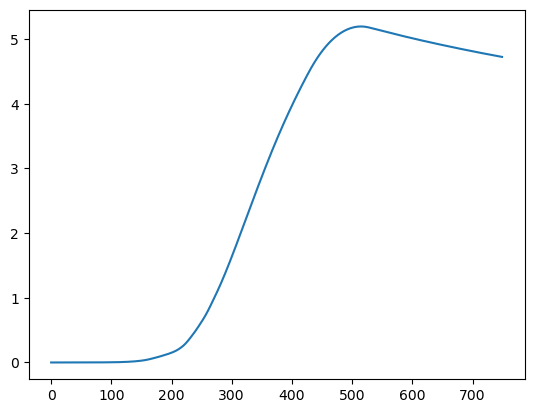

In [158]:
import matplotlib.pyplot as plt
plt.plot(out['GMST'])

In [8]:
import jax
import jax.numpy as jnp

# --- units: GtCO2/yr -> ppm/yr (for the simulator only)
PPM_PER_GTC   = 1.0 / 2.12         # ppm per GtC
GTC_PER_GTCO2 = 12.0 / 44.0        # GtC per GtCO2
def gtco2_per_year_to_ppm_per_year(E_gtco2_per_yr):
    E_gtco2_per_yr = jnp.asarray(E_gtco2_per_yr, dtype=jnp.float32)
    return E_gtco2_per_yr * GTC_PER_GTCO2 * PPM_PER_GTC

def _as_jnp(x):
    return x if isinstance(x, jnp.ndarray) else jnp.asarray(x, dtype=jnp.float32)


In [130]:
def make_features_E_and_cum_gtco2(
    E_gtco2_curr,                 # (T_cur,)
    E_gtco2_hist=None             # (T_hist,) or None
):
    """
    Causal features aligned to GMST at integer years:
      X[t, 0] = E_{t-1}      (previous-year emissions, GtCO2/yr)
      X[t, 1] = CumE_{t-1}   (cumulative GtCO2 up to previous year)

    If history is provided, year 0 uses the last historical year (no leakage).
    If no history, year 0 uses zeros.
    """
    Ec = _as_jnp(E_gtco2_curr).reshape(-1)                    # (T_cur,)
    T  = Ec.shape[0]

    if E_gtco2_hist is not None:
        Eh = _as_jnp(E_gtco2_hist).reshape(-1)                # (T_hist,)
        H  = Eh.shape[0]
        E_all   = jnp.concatenate([Eh, Ec], axis=0)           # (H+T,)

        # previous-year emissions for each current year index t = 0..T-1
        # indices: (H-1) .. (H+T-2)
        E_prev  = E_all[(H-1):(H-1+T)]

        # cumulative up to previous year
        Cum_all = jnp.cumsum(E_all)
        Cum_prev = Cum_all[(H-1):(H-1+T)]
    else:
        # No history: define previous-year emissions/cumulative at t=0 as 0.
        zero = jnp.array([0.0], dtype=Ec.dtype)
        E_prev   = jnp.concatenate([zero, Ec[:-1]], axis=0)   # (T,)
        Cum_curr = jnp.cumsum(Ec)
        Cum_prev = jnp.concatenate([zero, Cum_curr[:-1]], axis=0)  # (T,)

    X = jnp.stack([E_prev, Cum_prev], axis=1)                 # (T, 2)
    return X

In [10]:
def _infer_step(yrs: jnp.ndarray) -> jnp.ndarray:
    yrs = _as_jnp(yrs).reshape(-1)
    if yrs.size <= 1:
        return jnp.array(1.0, dtype=jnp.float32)
    return jnp.median(jnp.diff(yrs))

def _make_contiguous_years(yrs_hist: jnp.ndarray, yrs_curr: jnp.ndarray):
    """
    Rebase yrs_curr so its first point is exactly one step after yrs_hist[-1].
    Keeps the *spacing* of yrs_curr. If yrs_curr already follows yrs_hist,
    we leave it unchanged.
    """
    yrs_h = _as_jnp(yrs_hist).reshape(-1)
    yrs_c = _as_jnp(yrs_curr).reshape(-1)

    if (yrs_h.size == 0) or (yrs_c.size == 0):
        return jnp.concatenate([yrs_h, yrs_c]), yrs_c

    # If already contiguous (or strictly after), do nothing
    if yrs_c[0] > yrs_h[-1]:
        yrs_all = jnp.concatenate([yrs_h, yrs_c])
        return yrs_all, yrs_c

    # Otherwise, shift current so it starts one "curr step" after hist end
    step_c   = _infer_step(yrs_c)
    shift    = (yrs_h[-1] + step_c) - yrs_c[0]
    yrs_c_rb = yrs_c + shift
    yrs_all  = jnp.concatenate([yrs_h, yrs_c_rb])
    return yrs_all, yrs_c_rb

In [11]:
def simulate_targets_gmst_from_gtco2(
    years_curr,                  # (T_cur,)
    E_gtco2_curr,                # (T_cur,)
    years_hist=None,             # (T_hist,) or None
    E_gtco2_hist=None,           # (T_hist,) or None
    params=None,
    dt=0.1
):
    """
    Returns GMST over the current scenario's years using the JAX simulator.
    """

    yrs_c = _as_jnp(years_curr).reshape(-1)
    Em_c  = _as_jnp(E_gtco2_curr).reshape(-1)

    if years_hist is not None and E_gtco2_hist is not None:
        yrs_h = _as_jnp(years_hist).reshape(-1)
        Em_h  = _as_jnp(E_gtco2_hist).reshape(-1)

        yrs_all, yrs_c_rb = _make_contiguous_years(yrs_h, yrs_c)
        Eppm_all  = gtco2_per_year_to_ppm_per_year(jnp.concatenate([Em_h, Em_c], axis=0))
        out_all   = simulate_emissions(yrs_all, Eppm_all, params=(params or DEFAULT_PARAMS), dt=dt)
        # take GMST aligned to current years (last T_cur points)
        GMST_curr = out_all["GMST"][-Em_c.shape[0]:]
    else:
        Eppm_c  = gtco2_per_year_to_ppm_per_year(Em_c)
        out_c   = simulate_emissions(yrs_c, Eppm_c, params=(params or DEFAULT_PARAMS), dt=dt)
        GMST_curr = out_c["GMST"]

    return GMST_curr


In [12]:
def fit_scaler(X: jnp.ndarray, eps: float = 1e-8):
    mu = jnp.mean(X, axis=0)
    sd = jnp.sqrt(jnp.var(X, axis=0) + eps)
    Xs = (X - mu) / sd
    return Xs, (mu, sd)

def apply_scaler(X: jnp.ndarray, stats):
    mu, sd = stats
    return (X - mu) / sd


In [13]:
import numpy as np
def extract_years_and_E_gtco2(emis_entry_for_scenario):
    """
    Adapter: from run_fair's emis_dict[scenario] to (years, E_gtco2).
    Edit the TODO lines to match your dict structure.
    """
    # --- TODO: adjust these two lines to your actual structure
    years   = jnp.asarray(np.arange(0, len(emis_entry_for_scenario['CO2'])), dtype=jnp.float32)
    E_gtco2 = jnp.asarray(emis_entry_for_scenario["CO2"],  dtype=jnp.float32)  # GtCO2/yr
    # ---
    return years, E_gtco2


In [14]:
# Given from your snippet:
# agents = ['CO2']
# emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
# scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())
# delT_dict_tier1 = run_fair.get_delT(... )   # We'll use these only for sanity-check comparison.

def build_dataset_from_runfair_dict(emis_dict, scenarios, historical_name="historical"):
    """
    Returns a list of tuples for each scenario:
      (X_features, y_target, scenario_name)
    where:
      X_features = [E_gtco2, cumulative_gtco2] (scaled or unscaled, your choice)
      y_target   = GMST from the JAX simulator, aligned to current scenario years
    """
    # Extract historical series once, if present
    years_hist, E_hist = None, None
    if historical_name in emis_dict:
        years_hist, E_hist = extract_years_and_E_gtco2(emis_dict[historical_name])

    dataset = []
    for scen in scenarios:
        years_cur, E_cur = extract_years_and_E_gtco2(emis_dict[scen])
        needs_history = (scen != historical_name)

        # Features (stay in original units)
        X = make_features_E_and_cum_gtco2(
            E_gtco2_curr=E_cur,
            E_gtco2_hist=E_hist if needs_history else None
        )

        # Targets (generate with JAX simulator to ensure internal consistency)
        y = simulate_targets_gmst_from_gtco2(
            years_curr=years_cur,
            E_gtco2_curr=E_cur,
            years_hist=years_hist if needs_history else None,
            E_gtco2_hist=E_hist  if needs_history else None,
        )

        # Align y to X length (should already match, but be safe)
        N = min(X.shape[0], y.shape[0])
        X, y = X[:N], y[:N]
        dataset.append((X, y, scen))

    return dataset


In [15]:
def split_and_scale(train_dataset, test_dataset):
    """
    JAX-safe version: no NumPy calls on traced arrays.
    train_dataset / test_dataset: lists of (X, y, scen)
    Returns:
      train_scaled = [(X_s, y, scen), ...]
      test_scaled  = [(X_s, y, scen), ...]
      stats = (mu, sd)
    """
    # Concatenate train features along rows
    Xtr_list = [jnp.asarray(X, dtype=jnp.float32) for (X, _, _) in train_dataset]
    Xtr      = jnp.concatenate(Xtr_list, axis=0) if Xtr_list else jnp.zeros((0,2), jnp.float32)

    # Fit scaler on the concatenated train features
    Xtr_s, stats = fit_scaler(Xtr)

    # Slice standardized rows back per scenario
    train_scaled = []
    offset = 0
    for (X, y, scen) in train_dataset:
        n = X.shape[0]  # Python int (static)
        Xs_slice = Xtr_s[offset:offset+n]
        train_scaled.append((Xs_slice, jnp.asarray(y, dtype=jnp.float32), scen))
        offset += n

    # Apply scaler to test features
    test_scaled = []
    for (X, y, scen) in test_dataset:
        Xs = apply_scaler(jnp.asarray(X, dtype=jnp.float32), stats)
        test_scaled.append((Xs, jnp.asarray(y, dtype=jnp.float32), scen))

    return train_scaled, test_scaled, stats

In [16]:
agents = ['CO2']#,'CH4','N2O','Sulfur','BC']
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(agents)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, agents, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, agents, MIP='ScenarioMIP_tier2')

In [17]:
# 6.a) Build train/test sets using the new pipeline
train_data = build_dataset_from_runfair_dict(emis_dict_tier1, scenarios_tier1, historical_name="historical")
test_data  = build_dataset_from_runfair_dict(emis_dict_tier2,  scenarios_tier2,  historical_name="historical")

# 6.b) (Optional) Compare our simulated targets to run_fair's ΔT for a few scenarios
def rmse(a, b): return float(jnp.sqrt(jnp.mean((jnp.asarray(a)-jnp.asarray(b))**2)))

for (X, y_sim, scen) in train_data[:3]:
    # pull the original target from run_fair (if aligned)
    y_fair = jnp.asarray(delT_dict_tier1[scen], dtype=jnp.float32)[:y_sim.shape[0]]
    print(f"{scen:30s}  RMSE(sim vs run_fair): {rmse(y_sim, y_fair):.4f} K")

# 6.c) Scale with train stats and reshape for your LSTM (timesteps=1)
train_s, test_s, stats = split_and_scale(train_data, test_data)

# Example: take one scenario and prepare for your Keras LSTM
(Xs, y, scen) = train_s[0]
X_for_lstm = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))  # [samples, timesteps=1, features=2]
print(scen, "X_for_lstm:", X_for_lstm.shape, "y:", y.shape)


historical                      RMSE(sim vs run_fair): 0.2862 K
H-ext                           RMSE(sim vs run_fair): 3.6897 K
M                               RMSE(sim vs run_fair): 0.5376 K
historical X_for_lstm: (274, 1, 2) y: (274,)


In [126]:
import jax, jax.numpy as jnp
import optax

# ----- 1) simple MLP model -----
def init_mlp_params(key, in_dim, hidden=32):
    k1, k2, k3 = jax.random.split(key, 3)
    W1 = jax.random.normal(k1, (in_dim, hidden)) * (1.0 / jnp.sqrt(in_dim))
    b1 = jnp.zeros((hidden,))
    W2 = jax.random.normal(k2, (hidden, 1)) * (1.0 / jnp.sqrt(hidden))
    b2 = jnp.zeros((1,))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def mlp_forward(params, X):
    h = jnp.tanh(X @ params["W1"] + params["b1"])
    y = (h @ params["W2"] + params["b2"]).squeeze(-1)
    return y

# ----- 2) loss helpers -----
def mse(pred, y): return jnp.mean((pred - y)**2)

def train_unrolled(params0, Xtr_s, ytr, K=200, lr=1e-3, weight_decay=0.0):
    # optax AdamW for determinism (full-batch)
    optimizer = optax.adamw(lr, weight_decay=weight_decay)
    opt_state = optimizer.init(params0)

    def step(carry, _):
        params, opt_state = carry
        def loss_fn(p):
            yhat = mlp_forward(p, Xtr_s)
            return mse(yhat, ytr)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(step, (params0, opt_state), xs=None, length=K)
    return paramsK, losses

# ----- 3) evaluation on test set list -----
def eval_on_tests(params, test_scaled_list):
    if not test_scaled_list:
        return jnp.array(0.0, dtype=jnp.float32)
    errs = [mse(mlp_forward(params, X), y) for (X, y, _) in test_scaled_list]
    return jnp.mean(jnp.stack(errs))


In [127]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

def plot_mlp_predictions(params, Xs, y, metric="RMSE", title_prefix="MLP fit"):
    """
    Plot y (truth) vs yhat (MLP). Title is "<title_prefix> - <metric>: <value>".
    Not used under grad/JIT; safe to convert to NumPy for Matplotlib.
    """
    # Compute prediction
    yhat = mlp_forward(params, Xs)
    # Pick metric
    if metric.upper() == "RMSE":
        loss_val = float(jnp.sqrt(jnp.mean((yhat - y)**2)))
    else:  # default MSE
        loss_val = float(jnp.mean((yhat - y)**2))

    # Convert to NumPy for plotting
    y_np    = np.asarray(y)
    yhat_np = np.asarray(yhat)

    plt.figure(figsize=(8,3))
    plt.plot(y_np,    label="truth", alpha=0.8)
    plt.plot(yhat_np, label="pred",  alpha=0.8)
    plt.legend()
    plt.xlabel("time step")
    plt.ylabel("target")
    plt.title(f"{title_prefix} - {metric.upper()}: {loss_val:.4f}")
    plt.tight_layout()
    plt.show()


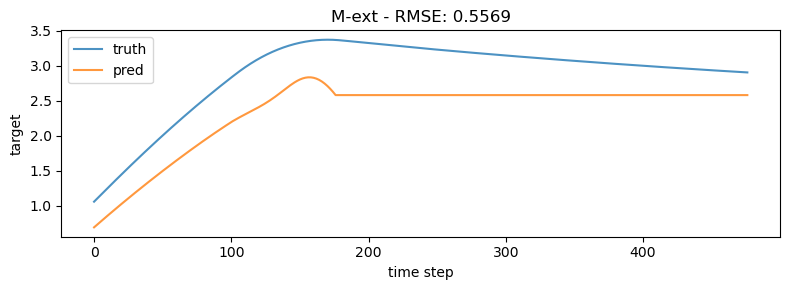

Train final loss: 0.3818457246031628
Test loss: 1.0857741050330243


In [128]:
# 0) Build datasets
train_data = build_dataset_from_runfair_dict(emis_dict_tier1, scenarios_tier1, historical_name="historical")
test_data  = build_dataset_from_runfair_dict(emis_dict_tier2,  scenarios_tier2,  historical_name="historical")

# 1) Scale with train stats (feature columns only)
train_s, test_s, stats = split_and_scale(train_data, test_data)

# 2) Concatenate train features/targets for training
import numpy as np
Xtr = jnp.asarray(np.vstack([np.asarray(X) for (X, _, _) in train_s]), dtype=jnp.float32)
ytr = jnp.asarray(np.concatenate([np.asarray(y) for (_, y, _) in train_s]), dtype=jnp.float32)

# 3) Init model and train (deterministic, full-batch)
key = jax.random.PRNGKey(0)
in_dim = Xtr.shape[1]   # should be 2 (E and cumulative E)
params0 = init_mlp_params(key, in_dim, hidden=32)

train_unrolled_jit = jax.jit(train_unrolled, static_argnames=("K",))
paramsK, losses = train_unrolled_jit(params0, Xtr, ytr, K=200, lr=1e-3, weight_decay=1e-4)

(Xs_demo, y_demo, scen_demo) = test_s[2]  # or train_s[0]
plot_mlp_predictions(paramsK, Xs_demo, y_demo, metric="RMSE", title_prefix=scen_demo)

# 4) Evaluate on tests
test_loss = eval_on_tests(paramsK, test_s)
print("Train final loss:", float(losses[-1]))
print("Test loss:", float(test_loss))


In [131]:
# Pick the first train scenario as "the training scenario" whose emissions we’ll differentiate
(X_tr1_s, y_tr1, scen_name_tr1) = train_s[0]

# We also need the *unscaled* features/targets builders + scaler so the grad can flow
# through: emissions -> features -> (fit scaler on full train) -> apply -> train -> test
# For simplicity, we rebuild the datasets inside the objective using the current emissions
# of just this one scenario, keeping all others as constants.

def objective_over_emissions(E_gtco2_train_scen):
    # 1) Rebuild features for the chosen training scenario (keeping history as you did originally)
    #    We need to pull the matching raw pieces from the original (unscaled) dataset.
    #    Find the original entry in train_data that matches scen_name_tr1:
    for (X_raw, y_raw, scen) in train_data:
        if scen == scen_name_tr1:
            # We don’t actually need X_raw here; we need the *history flag* and the original history arrays.
            break

    # Locate its raw emissions and years from your emis_dict
    years_hist, E_hist = None, None
    if "historical" in emis_dict_tier1:
        years_hist, E_hist = extract_years_and_E_gtco2(emis_dict_tier1["historical"])

    # Also get current years for this scenario
    years_cur, _E_cur_ignored = extract_years_and_E_gtco2(emis_dict_tier1[scen_name_tr1])

    # 1a) Build features from the *new* emissions (GtCO2) and cumulative (with history if needed)
    needs_history = (scen_name_tr1 != "historical")
    X_tr1_new = make_features_E_and_cum_gtco2(E_gtco2_train_scen,
                                              E_hist if needs_history else None)

    # 1b) Build target from simulator for this scenario (consistent with new emissions)
    y_tr1_new = simulate_targets_gmst_from_gtco2(years_cur, E_gtco2_train_scen,
                                                 years_hist if needs_history else None,
                                                 E_hist if needs_history else None)

    # 2) Rebuild the *full* train set = {this updated scenario} + {all other train scenarios unchanged}
    train_dataset_updated = [(X_tr1_new, y_tr1_new, scen_name_tr1)]
    for (X, y, scen) in train_data:
        if scen == scen_name_tr1:
            continue
        train_dataset_updated.append((X, y, scen))

    # 3) Scale using *train* stats, then build concatenated tensors
    train_s_updated, test_s_updated, _stats = split_and_scale(train_dataset_updated, test_data)
    X_chunks = [X for (X, _, _) in train_s_updated]   # these are already jnp arrays from split_and_scale
    y_chunks = [y for (_, y, _) in train_s_updated]
    Xtr_u = jnp.concatenate(X_chunks, axis=0) if X_chunks else jnp.zeros((0, 2), jnp.float32)
    ytr_u = jnp.concatenate(y_chunks, axis=0) if y_chunks else jnp.zeros((0,), jnp.float32)


    # 4) Train model for fixed K steps from the same init (for a well-defined mapping)
    paramsK_u, _ = train_unrolled(params0, Xtr_u, ytr_u, K=100, lr=1e-3, weight_decay=1e-4)

    # 5) Evaluate on tests
    return eval_on_tests(paramsK_u, test_s_updated)

# Build an initial emissions vector for the chosen scenario
_, E0_tr1 = extract_years_and_E_gtco2(emis_dict_tier1[scen_name_tr1])

# Take gradient wrt E_gtco2 (shape (T_tr1,))
objective_grad = jax.grad(objective_over_emissions)
g_E = objective_grad(jnp.asarray(E0_tr1, dtype=jnp.float32))

print("Grad wrt emissions shape:", g_E.shape)
print("||grad||:", float(jnp.linalg.norm(g_E)))


Grad wrt emissions shape: (274,)
||grad||: 0.0002789617865346372


In [132]:
import jax, jax.numpy as jnp
rng = jax.random.PRNGKey(0)

# U0 = initial emissions (GtCO2/yr) for the chosen scenario
U0 = jnp.asarray(E0_tr1, dtype=jnp.float32)

# Gradient at U0
g = jax.grad(objective_over_emissions)(U0)

# Random direction v (unit norm)
v = jax.random.normal(rng, U0.shape)
v = v / (jnp.linalg.norm(v) + 1e-12)

# Symmetric finite difference
def phi(alpha):
    return objective_over_emissions(U0 + alpha * v)

def finite_diff(eps):
    return (phi(eps) - phi(-eps)) / (2.0 * eps)

# Try a couple eps values (too big = truncation error, too small = FP noise)
for eps in [1e-1, 5e-2, 1e-2, 5e-3]:
    fd = finite_diff(eps)
    ad = jnp.dot(g, v)
    rel_err = jnp.abs(fd - ad) / (jnp.abs(fd) + jnp.abs(ad) + 1e-12)
    print(f"eps={eps:>6}  fd={float(fd): .6e}  ad={float(ad): .6e}  rel_err={float(rel_err): .3e}")


eps=   0.1  fd= 9.476395e-06  ad= 9.632315e-06  rel_err= 8.160e-03
eps=  0.05  fd= 1.139743e-05  ad= 9.632315e-06  rel_err= 8.393e-02
eps=  0.01  fd= 1.694464e-05  ad= 9.632315e-06  rel_err= 2.751e-01
eps= 0.005  fd= 8.833788e-06  ad= 9.632315e-06  rel_err= 4.324e-02


In [137]:
from jax import jvp
import jax, jax.numpy as jnp

U0 = jnp.asarray(E0_tr1, dtype=jnp.float32)
v  = jax.random.normal(jax.random.PRNGKey(1), U0.shape)
v  = v / (jnp.linalg.norm(v) + 1e-12)
v  = v.astype(U0.dtype)  # <- ensure same dtype (float32 here)

phi = objective_over_emissions

# JVP: forward-mode directional derivative dphi(U0)[v]
_, jvp_val = jvp(phi, (U0,), (v,))

# VJP: reverse-mode; grad • v
grad_phi = jax.grad(phi)(U0)
vjp_val  = jnp.dot(grad_phi, v)

print("JVP dir. deriv:", float(jvp_val))
print("VJP dir. deriv:", float(vjp_val))
print("abs diff:", float(jnp.abs(jvp_val - vjp_val)))


JVP dir. deriv: -4.2897511360496555e-05
VJP dir. deriv: -4.28975181421265e-05
abs diff: 6.781629945107337e-12


In [136]:
U0 = jnp.asarray(E0_tr1, dtype=jnp.float32)
g  = jax.grad(objective_over_emissions)(U0)

def L(U): return objective_over_emissions(U)

L0 = float(L(U0))
for alpha in [0.0, 1e-4, 5e-4, 1e-3, 2e-3, 2e-1]:
    U_new = U0 - alpha * g / (jnp.linalg.norm(g) + 1e-12)
    L_new = float(L(U_new))
    print(f"alpha={alpha: .1e}   L(U0)={L0: .6f}   L(U_new)={L_new: .6f}   Δ={L_new - L0: .3e}")


alpha= 0.0e+00   L(U0)= 2.771883   L(U_new)= 2.771883   Δ= 0.000e+00
alpha= 1.0e-04   L(U0)= 2.771883   L(U_new)= 2.771883   Δ= 8.661e-08
alpha= 5.0e-04   L(U0)= 2.771883   L(U_new)= 2.771882   Δ=-9.569e-08
alpha= 1.0e-03   L(U0)= 2.771883   L(U_new)= 2.771882   Δ=-3.937e-07
alpha= 2.0e-03   L(U0)= 2.771883   L(U_new)= 2.771882   Δ=-4.617e-07
alpha= 2.0e-01   L(U0)= 2.771883   L(U_new)= 2.771827   Δ=-5.524e-05


In [18]:
import jax, jax.numpy as jnp
import optax

# ----- LSTM params: arrays only (no ints), with explicit dtype -----
def init_lstm_params(key, in_dim, hidden=32, out_dim=1, dtype=jnp.float32):
    kW, kO = jax.random.split(key)

    # Make weights/biases in the requested dtype
    W  = jax.random.normal(kW, (in_dim + hidden, 4 * hidden), dtype=dtype)
    b  = jnp.zeros((4 * hidden,), dtype=dtype)
    Wo = jax.random.normal(kO, (hidden, out_dim), dtype=dtype)
    bo = jnp.zeros((out_dim,), dtype=dtype)

    # Scale in SAME dtype (avoid float64 promotion)
    scale_W  = jnp.array(1.0, dtype=dtype) / jnp.sqrt(jnp.array(in_dim + hidden, dtype=dtype))
    scale_Wo = jnp.array(1.0, dtype=dtype) / jnp.sqrt(jnp.array(hidden,        dtype=dtype))
    W  = W  * scale_W
    Wo = Wo * scale_Wo

    return {"W": W, "b": b, "Wo": Wo, "bo": bo}

def _hidden_size_from_params(params):
    return params["b"].shape[0] // 4

def _lstm_cell(params, carry, x_t):
    h, c = carry
    hidden = _hidden_size_from_params(params)

    # z is in params dtype (since we cast X to params dtype in forward)
    z = jnp.concatenate([x_t, h], axis=-1) @ params["W"] + params["b"]
    i = jax.nn.sigmoid(z[..., 0*hidden:1*hidden])
    f = jax.nn.sigmoid(z[..., 1*hidden:2*hidden])
    g = jnp.tanh(      z[..., 2*hidden:3*hidden])
    o = jax.nn.sigmoid(z[..., 3*hidden:4*hidden])
    c_new = f * c + i * g
    h_new = o * jnp.tanh(c_new)
    return (h_new, c_new), h_new

def lstm_forward(params, X):
    """
    X: (N, D) or (N, T, D). If (N, D), treated as T=1.
    Returns: (N,) via linear readout on final hidden.
    """
    # Coerce inputs to params dtype to prevent promotion
    pdt = params["W"].dtype
    X = X.astype(pdt)
    if X.ndim == 2:
        X = X[:, None, :]

    N, T, D = X.shape
    hidden = _hidden_size_from_params(params)
    h0 = jnp.zeros((N, hidden), dtype=pdt)
    c0 = jnp.zeros((N, hidden), dtype=pdt)

    def step(carry, x_t):
        return _lstm_cell(params, carry, x_t)

    # time-major scan; outputs keep dtype pdt
    (hT, _), _ = jax.lax.scan(step, (h0, c0), X.swapaxes(0, 1))
    y = (hT @ params["Wo"] + params["bo"]).squeeze(-1)
    return y

def mse(pred, y):
    pred = pred.astype(y.dtype)
    return jnp.mean((pred - y)**2)

def train_unrolled_lstm(params0, Xtr, ytr, K=200, lr=1e-3, weight_decay=0.0):
    # Ensure feature/target dtypes match params
    pdt = params0["W"].dtype
    Xtr = Xtr.astype(pdt)
    ytr = ytr.astype(pdt)

    optimizer = optax.adamw(lr, weight_decay=weight_decay)
    opt_state = optimizer.init(params0)

    def step(carry, _):
        params, opt_state = carry
        def loss_fn(p):
            yhat = lstm_forward(p, Xtr)
            return mse(yhat, ytr)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(step, (params0, opt_state), xs=None, length=K)
    return paramsK, losses


In [19]:
def eval_on_tests_lstm(params, test_scaled_list):
    if not test_scaled_list:
        return jnp.array(0.0, dtype=jnp.float32)
    errs = [mse(lstm_forward(params, X), y) for (X, y, _) in test_scaled_list]
    return jnp.mean(jnp.stack(errs))


In [20]:
def plot_lstm_predictions(params, Xs, y, metric="RMSE", title_prefix="LSTM fit"):
    yhat = lstm_forward(params, Xs)
    loss_val = float(jnp.sqrt(jnp.mean((yhat - y)**2))) if metric.upper()=="RMSE" else float(jnp.mean((yhat - y)**2))

    import numpy as np, matplotlib.pyplot as plt
    plt.figure(figsize=(8,3))
    plt.plot(np.asarray(y),    label="truth", alpha=0.8)
    plt.plot(np.asarray(yhat), label="pred",  alpha=0.8)
    plt.legend(); plt.xlabel("time step"); plt.ylabel("target")
    plt.title(f"{title_prefix} - {metric.upper()}: {loss_val:.4f}")
    plt.tight_layout(); plt.show()


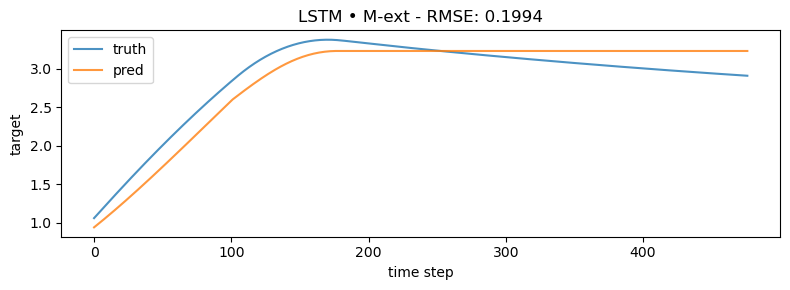

In [79]:
# After split_and_scale(...)
Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

key    = jax.random.PRNGKey(0)
in_dim = Xtr.shape[1]
hidden = 32

params0 = init_lstm_params(key, in_dim=in_dim, hidden=hidden, out_dim=1, dtype=jnp.float32)

train_unrolled_lstm_jit = jax.jit(train_unrolled_lstm, static_argnames=("K",))
paramsK, losses = train_unrolled_lstm_jit(params0, Xtr, ytr, K=50, lr=1e-2, weight_decay=1e-1)
(Xs_demo, y_demo, scen_demo) = test_s[2]
plot_lstm_predictions(paramsK, Xs_demo, y_demo, metric="RMSE", title_prefix=f"LSTM • {scen_demo}")



In [80]:
# --- RMSE helpers ---
def rmse(pred, y):
    pred = pred.astype(jnp.float32)
    y    = y.astype(jnp.float32)
    return jnp.sqrt(jnp.mean((pred - y)**2))

def eval_test_rmse_by_scenario(params, test_list):
    """Returns list of (scenario_name, rmse_value) for all tests."""
    out = []
    for (Xte, yte, scen_name) in test_list:
        yhat = lstm_forward(params, Xte)
        out.append((scen_name, rmse(yhat, yte)))
    return out

# --- compute per-scenario RMSEs and the average ---
rmse_list = eval_test_rmse_by_scenario(paramsK, test_s)          # [(name, rmse_jnp), ...]
avg_rmse  = jnp.mean(jnp.stack([r for (_, r) in rmse_list]))

# Print results
for name, r in rmse_list:
    print(f"{name:30s}  RMSE = {float(r):.6f}")
print(f"\nAverage test RMSE across {len(rmse_list)} scenarios: {float(avg_rmse):.6f}")


historical                      RMSE = 0.285280
H-ext-OS                        RMSE = 0.277365
M-ext                           RMSE = 0.199418
ML-ext                          RMSE = 2.402475
L-ext                           RMSE = 0.219752
VLHO-ext                        RMSE = 1.164327

Average test RMSE across 6 scenarios: 0.758103


In [39]:
import jax, jax.numpy as jnp

def make_objective_over_emissions(
    scen_name_tr1,                 # the training scenario whose emissions we optimize
    train_data,                    # list[(X, y, scen)] built by build_dataset_from_runfair_dict(...)
    test_data,                     # list[(X, y, scen)] from tier2 (or your choice)
    emis_dict_tier1,               # to fetch raw years/emissions for scen + historical
    params0,                       # fixed LSTM init params (arrays only!)
    historical_name="historical",  # name of the historical scenario
    dtype=jnp.float32
):
    """
    Returns: objective_over_emissions(E_gtco2_train_scen) -> scalar test loss
    NOTE: No NumPy ops on traced arrays inside. Keep everything jnp.*.
    """

    # Pull historical years/emissions once (if present)
    years_hist, E_hist = (None, None)
    if historical_name in emis_dict_tier1:
        years_hist, E_hist = extract_years_and_E_gtco2(emis_dict_tier1[historical_name])
        years_hist = jnp.asarray(years_hist, dtype=dtype)
        E_hist     = jnp.asarray(E_hist,     dtype=dtype)

    # Pull current scenario years once (emissions will be provided at call-time)
    years_cur, _E_ignore = extract_years_and_E_gtco2(emis_dict_tier1[scen_name_tr1])
    years_cur = jnp.asarray(years_cur, dtype=dtype)
    needs_history = (scen_name_tr1 != historical_name)

    # Build the objective that only takes emissions for the chosen scenario
    def objective_over_emissions(E_gtco2_train_scen):
        # 1) Features for the chosen training scenario (E and cumulative E, in GtCO2)
        X_tr1_new = make_features_E_and_cum_gtco2(
            jnp.asarray(E_gtco2_train_scen, dtype=dtype),
            E_hist if needs_history else None
        )

        # 2) Targets from the JAX simulator (GMST), using GtCO2->ppm conversion internally
        y_tr1_new = simulate_targets_gmst_from_gtco2(
            years_curr = years_cur,
            E_gtco2_curr = jnp.asarray(E_gtco2_train_scen, dtype=dtype),
            years_hist = years_hist if needs_history else None,
            E_gtco2_hist = E_hist if needs_history else None
        ).astype(dtype)

        # 3) Rebuild the *full* training dataset (this scenario updated, others constant)
        train_dataset_updated = [(X_tr1_new, y_tr1_new, scen_name_tr1)]
        for (X, y, scen) in train_data:
            if scen == scen_name_tr1:
                continue
            # X, y from train_data are already jnp arrays; ensure dtype
            train_dataset_updated.append((jnp.asarray(X, dtype=dtype),
                                          jnp.asarray(y, dtype=dtype),
                                          scen))

        # 4) Fit scaler on updated train set; apply to tests (JAX-safe splitter)
        train_s_updated, test_s_updated, _stats = split_and_scale(
            train_dataset_updated, test_data
        )

        # 5) Concatenate updated train tensors (JAX only)
        Xtr_u = jnp.concatenate([X for (X, _, _) in train_s_updated], axis=0).astype(dtype)
        ytr_u = jnp.concatenate([y for (_, y, _) in train_s_updated], axis=0).astype(dtype)

        # 6) Train unrolled LSTM for fixed K steps from same init (pure function)
        #paramsK_u, _ = train_unrolled_lstm_debug(
        #    params0, Xtr_u, ytr_u, K=10, lr=1e-4, weight_decay=1e-4
        #)
        paramsK_u, _ = train_unrolled_lstm_sgd(params0, Xtr_u, ytr_u, K=1000, lr=5e-2, weight_decay=1e-4)


        # 7) Evaluate on tests (mean MSE over scenarios)
        return eval_on_tests_lstm(paramsK_u, test_s_updated).astype(dtype)

    return objective_over_emissions


In [218]:
import jax, jax.numpy as jnp, optax

# ---- Tree utils: version-agnostic shims ----
try:
    # New API (>= 0.4.25): jax.tree.map / jax.tree.reduce
    from jax import tree as _jtree
    _tree_map    = _jtree.map
    _tree_reduce = _jtree.reduce
except Exception:
    # Fallback (any version): jax.tree_util.tree_map / tree_reduce
    from jax import tree_util as _jtree
    _tree_map    = _jtree.tree_map
    _tree_reduce = _jtree.tree_reduce

def tree_all_finite(tree):
    return _tree_reduce(
        lambda a, b: a & b,
        _tree_map(lambda x: jnp.all(jnp.isfinite(x)), tree),
        initializer=jnp.array(True),
    )

def tree_global_norm(tree):
    return jnp.sqrt(sum([jnp.sum(jnp.square(x)) for x in jax.tree.leaves(tree)]))

# ---- Debug trainer with gradient prints (dtype-safe, clipped, AdamW) ----
def train_unrolled_lstm_debug(params0, Xtr, ytr, K=200, lr=5e-4, weight_decay=1e-4):
    pdt = params0["W"].dtype
    Xtr = Xtr.astype(pdt); ytr = ytr.astype(pdt)

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(lr, weight_decay=weight_decay, eps=1e-7),
    )
    opt_state = optimizer.init(params0)

    def step(carry, i):
        params, opt_state = carry

        def loss_fn(p):
            yhat = lstm_forward(p, Xtr)
            return jnp.mean(jnp.square(yhat - ytr))

        loss, grads = jax.value_and_grad(loss_fn)(params)

        # Gradient diagnostics (works under jit/grad)
        g_finite = tree_all_finite(grads)
        g_norm   = tree_global_norm(grads)
        jax.debug.print("step {i} loss={l:.6f}  grad_finite={f}  grad_norm={n:.3e}",
                        i=i, l=loss, f=g_finite, n=g_norm)

        p_finite = tree_all_finite(params)
        os_finite = tree_all_finite(opt_state)
        jax.debug.print("step {i} params_finite={pf} opt_state_finite={of}",
                        i=i, pf=p_finite, of=os_finite)

        # Optional sanitize to prevent NaNs from propagating backward
        grads = _tree_map(lambda g: jnp.nan_to_num(g, nan=0.0, posinf=1e6, neginf=-1e6), grads)

        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(
        step, (params0, opt_state), xs=jnp.arange(K), length=K
    )
    return paramsK, losses


In [33]:
from jax import tree as _jtree
_tree_map    = _jtree.map
def train_unrolled_lstm_sgd(params0, Xtr, ytr, K=50, lr=5e-4, weight_decay=0.0):
    pdt = params0["W"].dtype
    Xtr = Xtr.astype(pdt); ytr = ytr.astype(pdt)

    optimizer = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.add_decayed_weights(weight_decay),
        optax.sgd(lr)   # plain SGD = ultra-stable backward
    )
    opt_state = optimizer.init(params0)

    def step(carry, i):
        params, opt_state = carry
        def loss_fn(p):
            yhat = lstm_forward(p, Xtr)
            return jnp.mean((yhat - ytr)**2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        grads = _tree_map(lambda g: jnp.nan_to_num(g, nan=0.0, posinf=1e6, neginf=-1e6), grads)
        updates, opt_state = optimizer.update(grads, opt_state, params=params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), loss

    (paramsK, opt_stateK), losses = jax.lax.scan(step, (params0, opt_state), xs=jnp.arange(K), length=K)
    return paramsK, losses


In [40]:
# Choose which training scenario’s emissions to optimize
scen_name_tr1 = 'historical'
_, E0_tr1 = extract_years_and_E_gtco2(emis_dict_tier1[scen_name_tr1])
E0_tr1 = jnp.asarray(E0_tr1, dtype=jnp.float32)

# Build the objective
objective_over_emissions = make_objective_over_emissions(
    scen_name_tr1=scen_name_tr1,
    train_data=train_data,
    test_data=test_data,
    emis_dict_tier1=emis_dict_tier1,
    params0=params0,
    historical_name="historical",
    dtype=jnp.float32
)

# Gradient check (should be non-zero)
jax.config.update("jax_debug_nans", True)
g_E = jax.grad(objective_over_emissions)(E0_tr1)
print("||grad||:", float(jnp.linalg.norm(g_E)))


||grad||: 0.0004157336661592126


In [41]:
# Gradient (should be non-zero)
U0 = jnp.asarray(E0_tr1, dtype=jnp.float32)
g  = jax.grad(objective_over_emissions)(U0)
print("||grad||:", float(jnp.linalg.norm(g)))

# Finite-difference direction check
rng = jax.random.PRNGKey(1)
v = jax.random.normal(rng, U0.shape); v = v / (jnp.linalg.norm(v) + 1e-12); v = v.astype(U0.dtype)
def phi(alpha): return objective_over_emissions(U0 + alpha * v)
for eps in [1e-2, 5e-3, 1e-3]:
    fd = (phi(eps) - phi(-eps)) / (2*eps)
    ad = jnp.dot(g, v)
    print(f"eps={eps:.0e}  fd={float(fd): .6e}  ad={float(ad): .6e}  relerr={float(jnp.abs(fd-ad)/(jnp.abs(fd)+jnp.abs(ad)+1e-12)):.2e}")

# JVP vs VJP
from jax import jvp
_, jvp_val = jvp(objective_over_emissions, (U0,), (v,))
vjp_val = jnp.dot(g, v)
print("JVP:", float(jvp_val), " VJP:", float(vjp_val), " |diff|:", float(jnp.abs(jvp_val - vjp_val)))


||grad||: 0.0004157336661592126
eps=1e-02  fd= 1.490116e-05  ad= 1.744887e-05  relerr=7.88e-02
eps=5e-03  fd= 2.384186e-05  ad= 1.744887e-05  relerr=1.55e-01
eps=1e-03  fd= 2.980232e-05  ad= 1.744887e-05  relerr=2.61e-01
JVP: 1.7448863218305632e-05  VJP: 1.744887231325265e-05  |diff|: 9.094947017729282e-12


In [64]:
def build_train_from_U(U_gtco2):
    """
    Returns a single-scenario train dataset:
      [(X, y, 'opt_scen')], where
        X[:,0] = E_gtco2 (current)
        X[:,1] = cumulative E_gtco2 (including history)
        y      = simulator GMST aligned to current timeline
    """
    U = jnp.asarray(U_gtco2, dtype=jnp.float32).reshape(-1)
    years_cur = jnp.arange(U.shape[0], dtype=jnp.float32)

    X = make_features_E_and_cum_gtco2(E_gtco2_curr=U, E_gtco2_hist=None)
    y = simulate_targets_gmst_from_gtco2(
            years_curr=years_cur,
            E_gtco2_curr=U,
            years_hist=None,
            E_gtco2_hist=None
        ).astype(jnp.float32)

    N = jnp.minimum(X.shape[0], y.shape[0])
    return [(X[:N], y[:N], "opt_scen")]

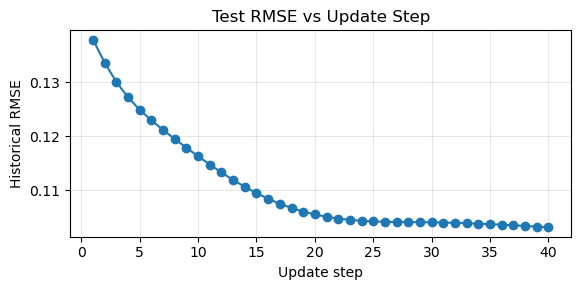

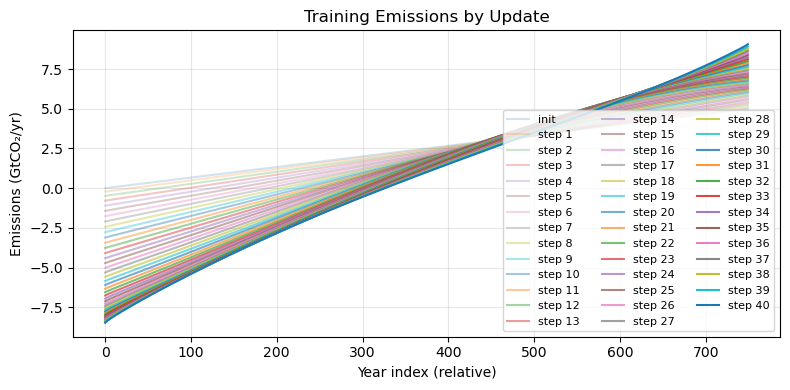

In [55]:
# ==== Inverse emissions optimization (new code) ==============================
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# --- 1) Initial emissions guess: slow ramp of length 750 (GtCO2/yr) ---
def init_slow_ramp(T=750, start_gtco2=0.0, end_gtco2=20.0, dtype=jnp.float32):
    return jnp.linspace(start_gtco2, end_gtco2, T, dtype=dtype)

# --- 2) Build train set from a candidate emissions vector U (GtCO2/yr) ---

# --- 3) Prepare test set = historical from tier 1 only ---
def build_test_historical_only(emis_dict_tier1, historical_name="historical"):
    test_ds = build_dataset_from_runfair_dict(
        emis_dict_tier1, [historical_name], historical_name=historical_name
    )
    return test_ds

# --- 4) Objective factory: given inner-train hyperparams, return objective(U) ---
def make_inverse_objective_single_train(
    params0,                      # LSTM init params (arrays)
    years_hist, E_hist_gtco2,     # historical timeline and E (GtCO2/yr)
    test_dataset,                 # list with one entry: historical
    K_inner=50,                   # unrolled optimizer steps for inner train
    lr_inner=5e-4,
    wd_inner=1e-4,
):
    def objective(U_gtco2):
        # Build updated single-scenario train set from U
        train_updated = build_train_from_U(U_gtco2, years_hist, E_hist_gtco2)

        # Fit scaler on updated train; apply to test
        train_s, test_s, _stats = split_and_scale(train_updated, test_dataset)

        # Concatenate train tensors
        Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
        ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

        # Train inner model (use SGD for stable hypergrad)
        paramsK, _ = train_unrolled_lstm_sgd(
            params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
        )

        # Evaluate on test (historical); return RMSE
        # eval_on_tests_lstm returns mean MSE; take sqrt
        mse_val = eval_on_tests_lstm(paramsK, test_s)
        return jnp.sqrt(mse_val + 1e-12)
    return objective

# --- 5) Top-level optimizer loop on U (gradient descent) ---
import optax

def optimize_emissions_inverse(
    emis_dict_tier1,
    params0,
    num_updates=20,
    step_size=1e-1,            # LR on U (GtCO2/yr)
    momentum=0.9,              # NEW: momentum (0→SGD, ~0.9 good)
    nesterov=True,             # NEW: use Nesterov momentum
    ramp_start=0.0,
    ramp_end=20.0,
    K_inner=50,
    lr_inner=5e-4,
    wd_inner=1e-4,
    historical_name="historical",
):
    # Historical series + test set (historical-only)
    years_hist, E_hist = extract_years_and_E_gtco2(emis_dict_tier1[historical_name])
    years_hist = jnp.asarray(years_hist, dtype=jnp.float32)
    E_hist     = jnp.asarray(E_hist,     dtype=jnp.float32)
    test_dataset = build_test_historical_only(emis_dict_tier1, historical_name=historical_name)

    # Objective(U) = historical test RMSE after inner train
    objective = make_inverse_objective_single_train(
        params0, years_hist, E_hist, test_dataset,
        K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner
    )
    grad_obj = jax.grad(objective)

    # Init U (slow ramp, length 750)
    U = init_slow_ramp(T=750, start_gtco2=ramp_start, end_gtco2=ramp_end)

    # Momentum optimizer on U (with gradient clipping)
    opt = optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.sgd(learning_rate=step_size, momentum=momentum, nesterov=nesterov),
    )
    opt_state = opt.init(U)

    # Storage
    errors = []
    U_traj = [U]

    # Outer loop
    for k in range(num_updates):
        gU = grad_obj(U)
        updates, opt_state = opt.update(gU, opt_state, params=U)
        U = optax.apply_updates(U, updates)
        err = float(objective(U))
        errors.append(err)
        U_traj.append(U)

    return {"U_traj": U_traj, "errors": jnp.asarray(errors, dtype=jnp.float32)}


# --- 6) Plot helpers ---
def plot_inverse_results(results):
    """
    results from optimize_emissions_inverse(...)
    - Plot 1: error (RMSE) vs update step
    - Plot 2: emissions time series per update (overlay)
    """
    errors = jnp.asarray(results["errors"])
    U_traj = results["U_traj"]

    # Plot error vs update
    plt.figure(figsize=(6,3))
    plt.plot(jnp.arange(1, errors.shape[0]+1), errors, marker='o')
    plt.xlabel("Update step")
    plt.ylabel("Historical RMSE")
    plt.title("Test RMSE vs Update Step")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Plot emissions evolution
    plt.figure(figsize=(8,4))
    for i, Ui in enumerate(U_traj):
        alpha = 0.2 + 0.8 * (i / max(1, len(U_traj)-1))
        lbl = "init" if i == 0 else f"step {i}"
        plt.plot(jnp.asarray(Ui), alpha=alpha, label=lbl)
    plt.xlabel("Year index (relative)")
    plt.ylabel("Emissions (GtCO₂/yr)")
    plt.title("Training Emissions by Update")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

# ==== Usage example (call from your notebook/script) =========================
results = optimize_emissions_inverse(
     emis_dict_tier1=emis_dict_tier1,
     params0=params0,
     num_updates=40,
     step_size=1e3,     # tune as needed
     ramp_start=0.0,
     ramp_end=5.0,
     K_inner=250,
     lr_inner=5e-4,
     wd_inner=1e-4,
 )
plot_inverse_results(results)


In [56]:
results['errors']

Array([0.13794182, 0.13366577, 0.13007908, 0.12722223, 0.12491409,
       0.12295079, 0.12117697, 0.11949851, 0.11787197, 0.116286  ,
       0.11474919, 0.11327815, 0.11189163, 0.11060679, 0.10943686,
       0.1083909 , 0.10747349, 0.10668545, 0.10602359, 0.10548153,
       0.10505035, 0.10471848, 0.10447314, 0.10430017, 0.10418516,
       0.10411436, 0.10407459, 0.10405408, 0.10404099, 0.10401614,
       0.10397601, 0.10392086, 0.10385223, 0.1037714 , 0.10367966,
       0.10357812, 0.10346728, 0.10334823, 0.10322089, 0.10308569],      dtype=float32)

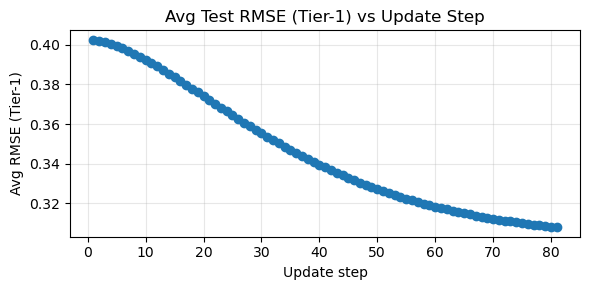

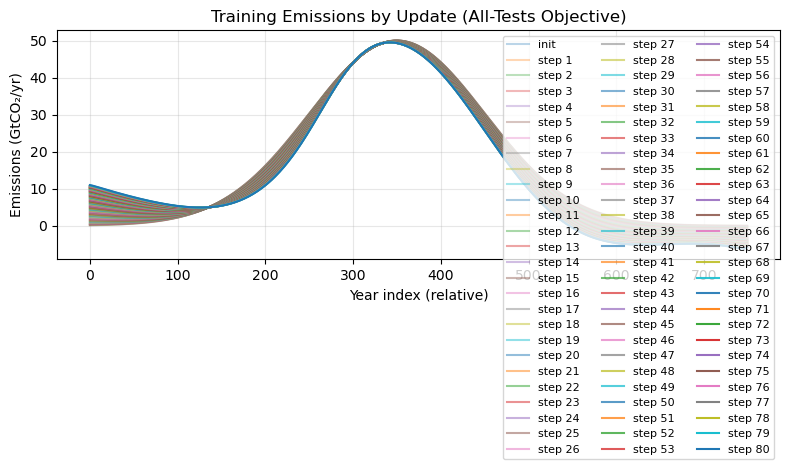

In [123]:
# ==== Inverse optimization over ALL Tier-1 scenarios (new code) ==============
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

def scale_by_coord(weights: jnp.ndarray) -> optax.GradientTransformation:
    """Multiply per-coordinate updates by 'weights' (same shape as U)."""
    def init_fn(_): return ()
    def update_fn(updates, state, params=None):
        upd = jax.tree.map(lambda u: u * weights, updates)  # pytree-safe
        return upd, state
    return optax.GradientTransformation(init_fn, update_fn)

def make_time_weights(T: int, power: float = 2.0, min_scale: float = 0.1) -> jnp.ndarray:
    """
    0..1 ramp^power, then mapped to [min_scale, 1]. Early years get smaller steps.
    """
    x = jnp.linspace(0.0, 1.0, T)
    w = x ** power
    return min_scale + (1.0 - min_scale) * w  # shape (T,)

def collect_init_final_preds(params_init, params_final, test_scaled_list):
    """
    For each scenario in test_scaled_list, return a record:
      {
        'scenario': name,
        'y_true':        (T,),
        'y_pred_init':   (T,),
        'y_pred_final':  (T,),
      }
    """
    out = []
    for (X, y, scen) in test_scaled_list:
        y0 = lstm_forward(params_init,  X)
        yK = lstm_forward(params_final, X)
        out.append({
            "scenario": scen,
            "y_true": y,
            "y_pred_init": y0,
            "y_pred_final": yK,
        })
    return out

def _train_inner_and_preds(params0, U, test_dataset,
                           K_inner, lr_inner, wd_inner):
    """
    Build the *single* training scenario from U, fit scaler, train inner model,
    evaluate test RMSE, and collect initial/final predictions per scenario.
    Returns (rmse, preds_list, paramsK).
    """
    # Build updated train set (single scenario from U)
    train_updated = build_train_from_U(U)

    # Scale with updated train stats; apply to tests
    train_s, test_s, _stats = split_and_scale(train_updated, test_dataset)

    # Concatenate train tensors
    Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
    ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

    # Inner training (SGD is robust for hypergrads)
    paramsK, _ = train_unrolled_lstm_sgd(
        params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
    )

    # Test RMSE across provided test scenarios
    mse_val = eval_on_tests_lstm(paramsK, test_s)
    rmse_val = jnp.sqrt(mse_val + 1e-12)

    # Collect initial (params0) and final (paramsK) predictions for each scenario
    preds = collect_init_final_preds(params0, paramsK, test_s)
    return rmse_val, preds, paramsK

# --- Build test set = ALL Tier-1 scenarios (including historical) -----------
def build_test_tier1_all(emis_dict_tier1, scenarios_tier1, historical_name="historical"):
    return build_dataset_from_runfair_dict(
        emis_dict_tier1, scenarios_tier1, historical_name=historical_name
    )

# --- Average RMSE over a test list ------------------------------------------
def avg_rmse_over_tests(params, test_list):
    # Compute per-scenario RMSE then average
    rmses = []
    for (Xte, yte, _) in test_list:
        yhat = lstm_forward(params, Xte)
        rmse_s = jnp.sqrt(jnp.mean((yhat - yte) ** 2))
        rmses.append(rmse_s)
    return jnp.mean(jnp.stack(rmses)) if rmses else jnp.array(0.0, dtype=jnp.float32)

# --- Objective(U): train on U, evaluate mean RMSE over ALL Tier-1 tests -----
def make_inverse_objective_single_train_alltests(
    params0,                      # LSTM init params (arrays)
    test_dataset_all,             # ALL Tier-1 scenarios as tests
    K_inner=50,                   # unrolled steps for inner train
    lr_inner=5e-4,
    wd_inner=1e-4,
):
    def objective(U_gtco2):
        # 1) Single training scenario from U
        train_updated = build_train_from_U(U_gtco2)

        # 2) Scale with updated train stats; apply to ALL tests
        train_s, test_s, _stats = split_and_scale(train_updated, test_dataset_all)

        # 3) Concatenate train tensors
        Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
        ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

        # 4) Inner training (SGD is robust for hypergrads)
        paramsK, _ = train_unrolled_lstm_sgd(
            params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
        )

        # 5) Return average RMSE across ALL Tier-1 scenarios
        return avg_rmse_over_tests(paramsK, test_s)
    return objective

# --- Outer loop with momentum on U (Nesterov SGD) ---------------------------
def optimize_emissions_inverse_alltests(
    emis_dict_tier1,
    scenarios_tier1,
    params0,
    num_updates=20,
    step_size=1e-1,            # LR on U (GtCO2/yr)
    momentum=0.9,              # momentum for faster convergence
    nesterov=True,
    K_inner=50,
    lr_inner=5e-4,
    wd_inner=1e-4,
    historical_name="historical",
):
    # Historical series + ALL Tier-1 tests
    years_hist, E_hist = extract_years_and_E_gtco2(emis_dict_tier1[historical_name])
    years_hist = jnp.asarray(years_hist, dtype=jnp.float32)
    E_hist     = jnp.asarray(E_hist,     dtype=jnp.float32)
    test_dataset_all = build_test_tier1_all(
        emis_dict_tier1, scenarios_tier1, historical_name=historical_name
    )

    # Objective(U): mean RMSE across ALL Tier-1 scenarios
    objective = make_inverse_objective_single_train_alltests(
        params0, test_dataset_all,
        K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner
    )
    grad_obj = jax.grad(objective)

    # Initialize U
    U = init_gaussian_emissions(T=750)

    rmse0, preds_init, _paramsK0 = _train_inner_and_preds(
        params0, U, test_dataset_all,
        K_inner, lr_inner, wd_inner
    )

    # Momentum optimizer on U (with gradient clipping)
    T = 750
    time_weights = make_time_weights(T=T, power=2.0, min_scale=0.15)
    opt = optax.chain(
        optax.clip_by_global_norm(1.0),
        scale_by_coord(time_weights),
        optax.sgd(learning_rate=step_size, momentum=momentum, nesterov=nesterov),
    )
    opt_state = opt.init(U)

    # Storage
    errors = [float(rmse0)]
    U_traj = [U]

    def objective(U_):
        rmse_val, _preds, _ = _train_inner_and_preds(
            params0, U_, test_dataset_all,
            K_inner, lr_inner, wd_inner
        )
        return rmse_val

    grad_obj = jax.grad(objective)

    for k in range(num_updates):
        gU = grad_obj(U)
        updates, opt_state = opt.update(gU, opt_state, params=U)
        U = optax.apply_updates(U, updates)
        rmse_k = float(objective(U))
        errors.append(rmse_k)
        U_traj.append(U)

    _rmse_final, preds_final, _paramsKf = _train_inner_and_preds(
        params0, U, test_dataset_all,
        K_inner, lr_inner, wd_inner
    )

    return {
        "U_traj": U_traj,                          # emissions path per update
        "errors": jnp.asarray(errors, jnp.float32),# avg RMSE per update (includes initial)
        "predictions_init": preds_init,            # list[ {scenario, y_true, y_pred_init, y_pred_final} ]
        "predictions_final": preds_final,          # list[ ... ] after final U
    }

# --- Plotting (reuse from previous version) ---------------------------------
def plot_inverse_results_alltests(results):
    errors = jnp.asarray(results["errors"])
    U_traj = results["U_traj"]

    # Error vs update
    plt.figure(figsize=(6,3))
    plt.plot(jnp.arange(1, errors.shape[0]+1), errors, marker='o')
    plt.xlabel("Update step"); plt.ylabel("Avg RMSE (Tier-1)")
    plt.title("Avg Test RMSE (Tier-1) vs Update Step")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    # Emissions evolution
    plt.figure(figsize=(8,4))
    for i, Ui in enumerate(U_traj):
        alpha = 0.3 + 0.7 * (i / max(1, len(U_traj)-1))
        lbl = "init" if i == 0 else f"step {i}"
        plt.plot(jnp.asarray(Ui), alpha=alpha, label=lbl)
    plt.xlabel("Year index (relative)")
    plt.ylabel("Emissions (GtCO₂/yr)")
    plt.title("Training Emissions by Update (All-Tests Objective)")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

def plot_init_final_per_scenario(preds, max_cols=2):
    """
    preds: list of dicts from predictions_init or predictions_final
           Each dict has: scenario, y_true, y_pred_init, y_pred_final
    Produces one figure with subplots per scenario.
    """
    import numpy as np, matplotlib.pyplot as plt
    n = len(preds)
    ncols = max_cols
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(5*ncols, 2.5*nrows))
    for i, rec in enumerate(preds, 1):
        ax = plt.subplot(nrows, ncols, i)
        y  = np.asarray(rec["y_true"])
        y0 = np.asarray(rec["y_pred_init"])
        yK = np.asarray(rec["y_pred_final"])
        ax.plot(y,  label="truth", lw=2, alpha=0.9)
        ax.plot(y0, label="init pred", alpha=0.8)
        ax.plot(yK, label="final pred", alpha=0.8)
        ax.set_title(rec["scenario"])
        ax.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()

# ==== Example usage ==========================================================
results_all = optimize_emissions_inverse_alltests(
     emis_dict_tier1=emis_dict_tier1,
     scenarios_tier1=scenarios_tier1,
     params0=params0,
     num_updates=80,
     step_size=1e3,
     momentum=0.9,
     nesterov=True,
     K_inner=200,
     lr_inner=5e-2,
     wd_inner=1e-2,
 )
plot_inverse_results_alltests(results_all)


Found 1600, starting from here...


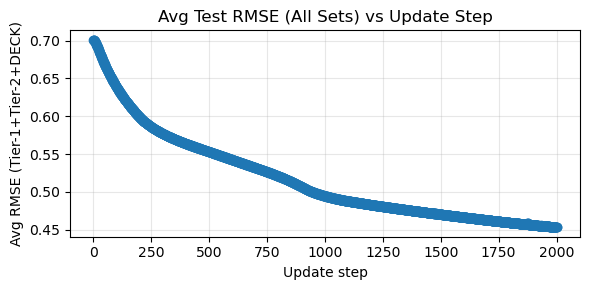

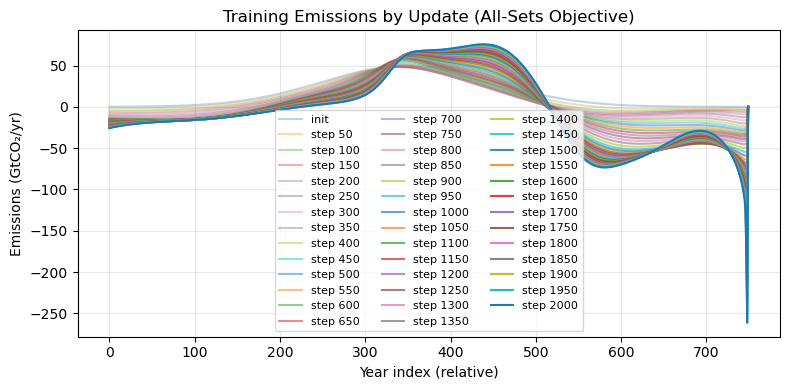

In [155]:
# ==== New / edited code to optimize over Tier-1 + Tier-2 + DECK ==============

# -- Helpers to build test datasets -------------------------------------------
def build_dataset_no_history(emis_dict, scenarios):
    """
    Build features/targets without prepending historical emissions.
    Uses a sentinel historical_name that won't be found in the dict.
    """
    return build_dataset_from_runfair_dict(
        emis_dict, scenarios, historical_name="__NONE__"
    )

def build_test_all_sets(
    emis_dict_tier1, scenarios_tier1,
    emis_dict_tier2, scenarios_tier2,
    emis_dict_deck,  scenarios_deck_subset,
    historical_name="historical",
):
    """
    Combined test list:
      - Tier-1 with historical context (where applicable)
      - Tier-2 with historical context (where applicable)
      - DECK subset with NO historical prepended
    """
    test_t1   = build_dataset_from_runfair_dict(emis_dict_tier1, scenarios_tier1, historical_name=historical_name)
    test_t2   = build_dataset_from_runfair_dict(emis_dict_tier2, scenarios_tier2,   historical_name=historical_name)
    test_deck = build_dataset_no_history(emis_dict_deck, scenarios_deck_subset)
    return test_t1 + test_t2 + test_deck

# -- Objective(U): train on U, evaluate mean RMSE over ALL sets ---------------
def make_inverse_objective_single_train_allsets(
    params0,                      # LSTM init params (arrays)
    test_dataset_all,             # Tier-1 + Tier-2 + DECK-subset
    K_inner=50,                   # unrolled steps for inner train
    lr_inner=5e-4,
    wd_inner=1e-4,
):
    def objective(U_gtco2):
        # 1) Single training scenario from U
        train_updated = build_train_from_U(U_gtco2)

        # 2) Scale with updated train stats; apply to ALL tests
        train_s, test_s, _stats = split_and_scale(train_updated, test_dataset_all)

        # 3) Concatenate train tensors
        Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
        ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

        # 4) Inner training (SGD is robust for hypergrads)
        paramsK, _ = train_unrolled_lstm_sgd(
            params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
        )

        # 5) Return average RMSE across ALL scenarios
        return avg_rmse_over_tests(paramsK, test_s)
    return objective

# ====== Checkpoint utils (drop-in) ===========================================
import os, pickle, numpy as np
from functools import partial

def _tree_to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(jax.device_get(x)) if isinstance(x, (jnp.ndarray, jax.Array)) else x, tree
    )

def _tree_to_jnp(tree):
    return jax.tree_util.tree_map(
        lambda x: jnp.asarray(x) if isinstance(x, np.ndarray) else x, tree
    )

def save_inverse_ckpt(path, state):
    """
    state keys (suggested):
      - "U_traj": list of jnp arrays (length = updates_done+1, includes init)
      - "errors": list/array of floats (same length as U_traj)
      - "opt_state": optax optimizer state PyTree
      - "step_count": int (number of completed updates)
      - "time_weights": jnp array or None
      - "meta": dict with hyperparams (to sanity-check resume)
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    safe = {
        "U_traj": [_tree_to_numpy(u) for u in state["U_traj"]],
        "errors": np.asarray(state["errors"]),
        "opt_state": _tree_to_numpy(state["opt_state"]),
        "step_count": int(state["step_count"]),
        "time_weights": _tree_to_numpy(state.get("time_weights", None)),
        "meta": state.get("meta", {}),
    }
    with open(path, "wb") as f:
        pickle.dump(safe, f)

def load_inverse_ckpt(path):
    with open(path, "rb") as f:
        raw = pickle.load(f)
    out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
    }
    return out

# ====== Resume-capable optimizer wrapper (drop-in replacement) ===============
def optimize_emissions_inverse_allsets(
    emis_dict_tier1, scenarios_tier1,
    emis_dict_tier2, scenarios_tier2,
    emis_dict_deck,  scenarios_deck_subset,
    params0,
    num_updates=20,
    step_size=1e-1,            # LR on U (GtCO2/yr)
    momentum=0.9,              # momentum for faster convergence
    nesterov=True,
    K_inner=50,
    lr_inner=5e-4,
    wd_inner=1e-4,
    historical_name="historical",
    # --- NEW: checkpoint options ---
    checkpoint_path=None,      # e.g., "checkpoints/inverse_allsets.pkl"
    checkpoint_every=10,       # save every N updates
    resume_if_exists=True,
):
    # Build combined test dataset (Tier-1 + Tier-2 + DECK-subset)
    test_dataset_all = build_test_all_sets(
        emis_dict_tier1, scenarios_tier1,
        emis_dict_tier2, scenarios_tier2,
        emis_dict_deck,  scenarios_deck_subset,
        historical_name=historical_name,
    )

    # Objective(U): mean RMSE across ALL scenarios
    objective = make_inverse_objective_single_train_allsets(
        params0, test_dataset_all,
        K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner
    )

    # Define optimizer (must match across resume runs)
    T = 750
    time_weights = make_time_weights(T=T, power=2.0, min_scale=0.15)
    opt = optax.chain(
        optax.clip_by_global_norm(1.0),
        scale_by_coord(time_weights),
        optax.sgd(learning_rate=step_size, momentum=momentum, nesterov=nesterov),
    )

    # Try to resume from checkpoint
    updates_done = 0
    if resume_if_exists and checkpoint_path and os.path.isfile(checkpoint_path):
        ckpt = load_inverse_ckpt(checkpoint_path)
        # Sanity-check meta hyperparams (warn only; you can raise if preferred)
        meta_old = ckpt.get("meta", {})
        meta_new = dict(step_size=step_size, momentum=momentum, nesterov=nesterov,
                        K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner, T=T)
        # (Optional) you could assert they match; here we continue.
        U_traj = ckpt["U_traj"]                 # includes initial U
        errors = ckpt["errors"].tolist()
        U = U_traj[-1]
        opt_state = ckpt["opt_state"]           # restored optax state
        updates_done = ckpt["step_count"]
        print(f'Found {updates_done}, starting from here...')
    else:
        # Fresh start: initialize U and opt_state
        U = init_gaussian_emissions(T=T)
        # Initial evaluation + preds snapshot (preds not stored in ckpt to keep it small)
        rmse0, _preds_init, _paramsK0 = _train_inner_and_preds(
            params0, U, test_dataset_all,
            K_inner, lr_inner, wd_inner
        )
        opt_state = opt.init(U)
        U_traj = [U]
        errors = [float(rmse0)]
        updates_done = 0
        print('No checkpoint found, starting fresh...')

    # Gradient of objective wrt U
    grad_obj = jax.grad(lambda U_: _train_inner_and_preds(
        params0, U_, test_dataset_all, K_inner, lr_inner, wd_inner
    )[0])

    # Run only the remaining updates if resuming
    remaining = max(0, num_updates - updates_done)
    for k in range(remaining):
        gU = grad_obj(U)
        updates, opt_state = opt.update(gU, opt_state, params=U)
        U = optax.apply_updates(U, updates)
        rmse_k, _, _ = _train_inner_and_preds(
            params0, U, test_dataset_all,
            K_inner, lr_inner, wd_inner
        )
        errors.append(float(rmse_k))
        U_traj.append(U)
        updates_done += 1

        # periodic checkpoint
        if checkpoint_path and ((updates_done % checkpoint_every) == 0):
            save_inverse_ckpt(checkpoint_path, {
                "U_traj": U_traj,
                "errors": errors,
                "opt_state": opt_state,
                "step_count": updates_done,
                "time_weights": time_weights,
                "meta": dict(step_size=step_size, momentum=momentum, nesterov=nesterov,
                             K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner, T=T),
            })

    # Final snapshot (always save if path provided)
    if checkpoint_path:
        save_inverse_ckpt(checkpoint_path, {
            "U_traj": U_traj,
            "errors": errors,
            "opt_state": opt_state,
            "step_count": updates_done,
            "time_weights": time_weights,
            "meta": dict(step_size=step_size, momentum=momentum, nesterov=nesterov,
                         K_inner=K_inner, lr_inner=lr_inner, wd_inner=wd_inner, T=T),
        })

    # Final evaluation/preds (not stored to ckpt by default)
    _rmse_final, preds_final, _paramsKf = _train_inner_and_preds(
        params0, U, test_dataset_all,
        K_inner, lr_inner, wd_inner
    )

    return {
        "U_traj": U_traj,                              # emissions path per update (len = updates_done+1)
        "errors": jnp.asarray(errors, jnp.float32),    # avg RMSE per update (includes initial)
        "predictions_final": preds_final,              # per-scenario preds at the end
        "updates_done": updates_done,                  # number of completed updates
        "checkpoint_path": checkpoint_path,
    }

# ==== Example usage (swap to new API) ========================================
results_allsets = optimize_emissions_inverse_allsets(
    emis_dict_tier1=emis_dict_tier1, scenarios_tier1=scenarios_tier1,
    emis_dict_tier2=emis_dict_tier2, scenarios_tier2=scenarios_tier2,
    emis_dict_deck=emis_dict_DECK,   scenarios_deck_subset=scenarios_DECK_subset,
    params0=params0,
    num_updates=2000,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=200,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path="checkpoints/inverse_allsets.pkl",
    checkpoint_every=10,
    resume_if_exists=True,
 )
plot_inverse_results_allsets(results_allsets)


In [160]:
## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

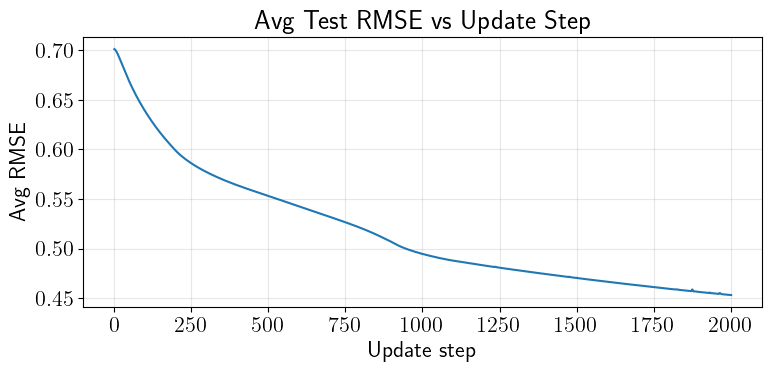

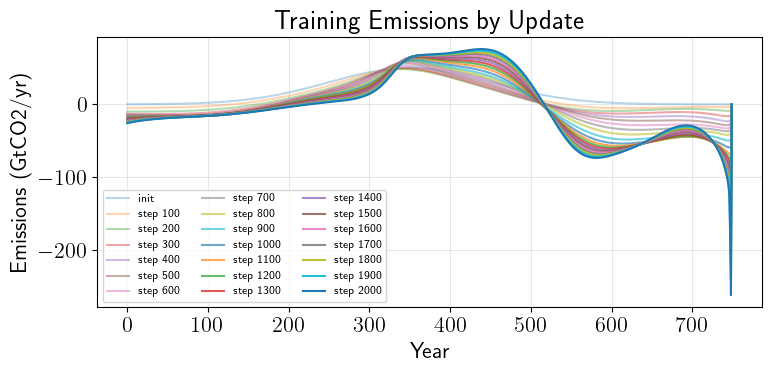

In [173]:
# -- Optional: slightly tweaked title for the combined-sets plot --------------
def plot_inverse_results_allsets(results):
    errors = jnp.asarray(results["errors"])
    U_traj = results["U_traj"]

    # Error vs update
    plt.figure(figsize=(8,4))
    plt.plot(jnp.arange(1, errors.shape[0]+1), errors)
    plt.xlabel("Update step")
    plt.ylabel("Avg RMSE")
    plt.title("Avg Test RMSE vs Update Step")
    plt.grid(True, alpha=0.3); plt.tight_layout()

    # Emissions evolution
    plt.figure(figsize=(8,4))
    for i, Ui in enumerate(U_traj):
        if i % 100 == 0:
            alpha = 0.3 + 0.7 * (i / max(1, len(U_traj)-1))
            lbl = "init" if i == 0 else f"step {i}"
            plt.plot(jnp.asarray(Ui), alpha=alpha, label=lbl)
    plt.xlabel("Year")
    plt.ylabel("Emissions (GtCO2/yr)")
    plt.title("Training Emissions by Update")
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

plot_inverse_results_allsets(results_allsets)

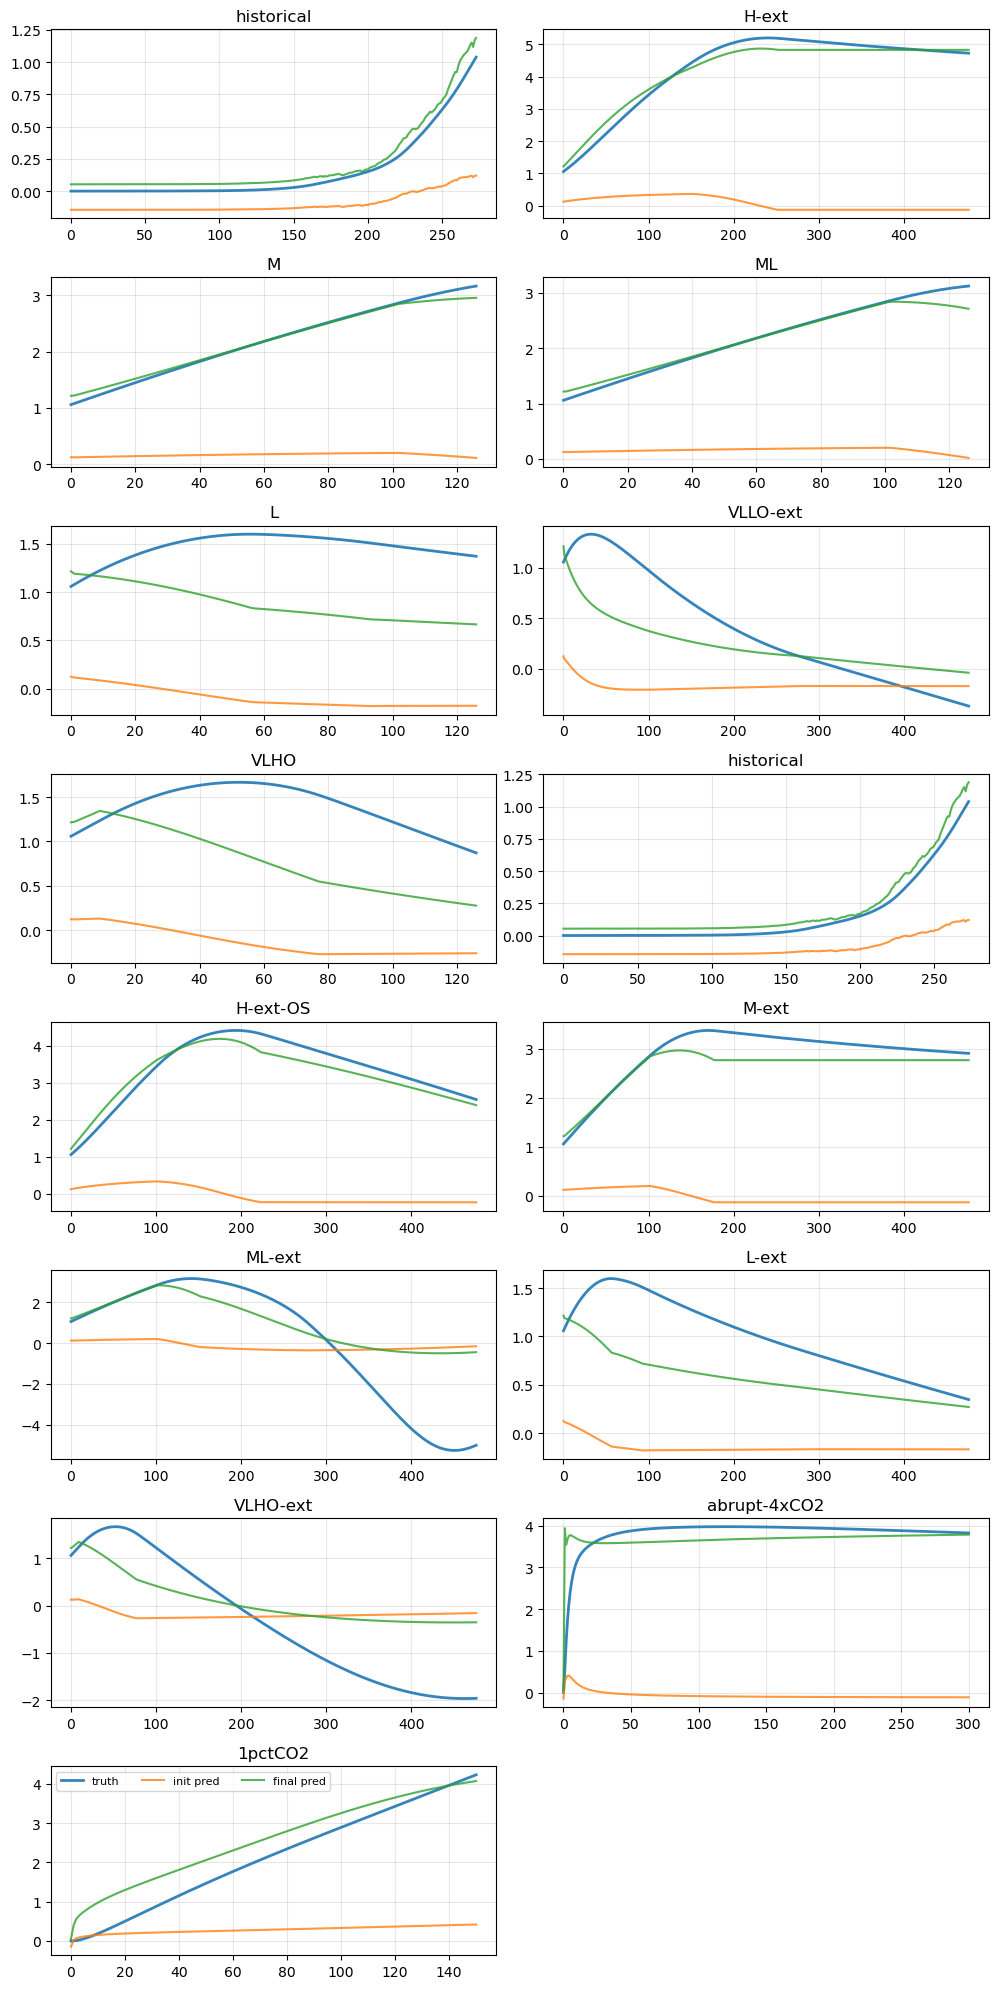

In [143]:
plot_init_final_per_scenario(results_allsets['predictions_init'])

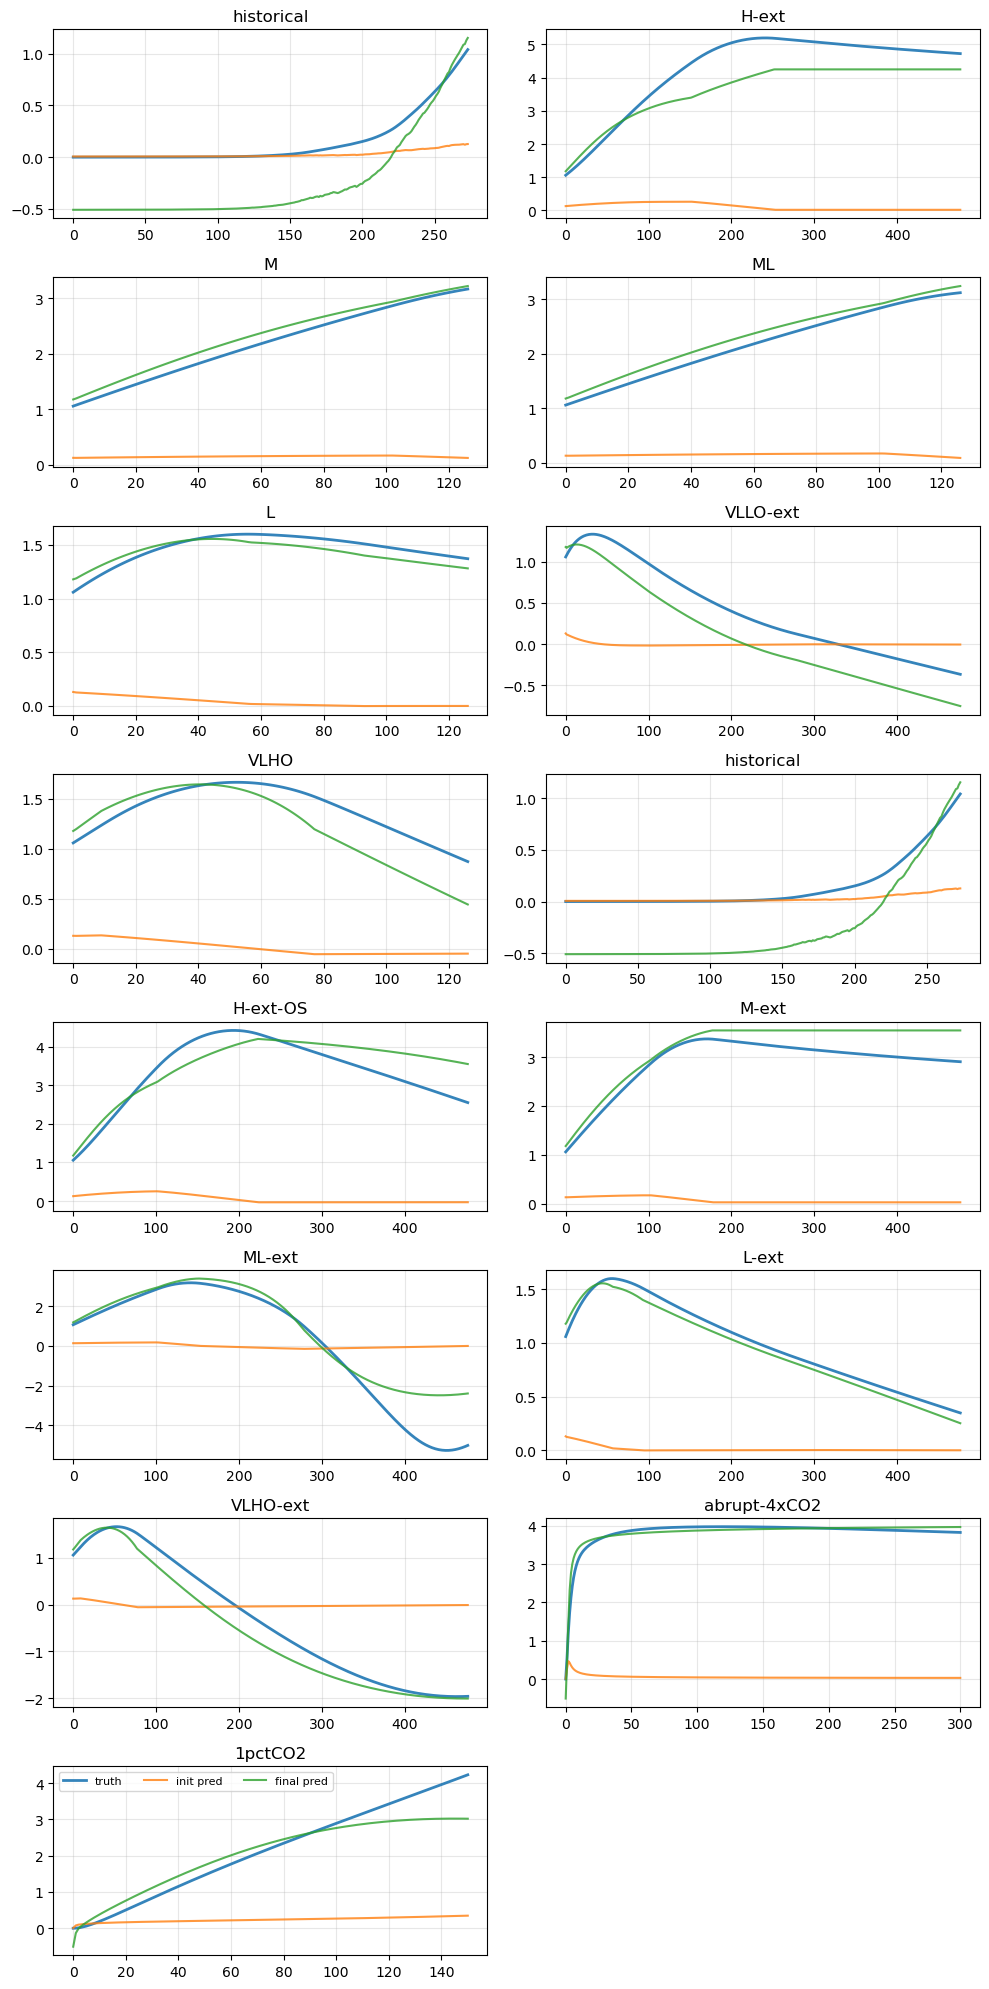

In [156]:
plot_init_final_per_scenario(results_allsets['predictions_final'])

In [ ]:
scen = next(s for s in scenarios_tier1 if s != "historical")
years_hist, E_hist = extract_years_and_E_gtco2(emis_dict_tier1["historical"])
years_cur,  E_cur  = extract_years_and_E_gtco2(emis_dict_tier1[scen])

X = make_features_E_and_cum_gtco2(E_cur, E_hist)  # (T, 2) -> [E, cumE]
cum0 = float(X[0,1])
print("First cumulative value:", cum0, "≈ sum(history):", float(jnp.sum(E_hist)))

In [104]:
def init_high_emissions_tanh(
    T: int,
    peak_gtco2: float = 50.0,   # peak emissions (GtCO2/yr)
    t_rise: int = 200,          # center of sharp rise (years since start)
    w_rise: float = 30.0,       # rise sharpness (smaller = sharper)
    t_fall: int = 520,          # center of decline (start falling after this)
    w_fall: float = 200.0,      # decline smoothness (larger = slower fall)
    floor: float = 0.0,         # near-zero baseline before the rise
    tail_floor: float = 0.5,    # asymptotic floor after the decline
    dtype=jnp.float32,
) -> jnp.ndarray:
    """
    High-emissions shape using tanh gates:
      - ~0 for first ~t_rise years,
      - sharp rise around t_rise,
      - slow decline after ~t_fall toward 'tail_floor'.

    E(t) = floor
         + peak * rise(t) * fall(t)
         + tail_floor * rise(t) * (1 - fall(t))

    where rise(t) = 0.5*(tanh((t - t_rise)/w_rise) + 1)
          fall(t) = 0.5*(tanh((t_fall - t)/w_fall) + 1)
    """
    t = jnp.arange(T, dtype=dtype)
    rise = 0.5 * (jnp.tanh((t - jnp.array(t_rise, dtype=dtype)) / jnp.array(w_rise, dtype=dtype)) + 1.0)
    fall = 0.5 * (jnp.tanh((jnp.array(t_fall, dtype=dtype) - t) / jnp.array(w_fall, dtype=dtype)) + 1.0)

    peak_term = peak_gtco2 * rise * fall                 # builds the peak that later declines
    tail_term = tail_floor * rise * (1.0 - fall)         # slow landing after the peak
    E = floor + peak_term + tail_term

    # Safety: nonnegative and finite
    return jnp.maximum(jnp.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0), 0.0).astype(dtype)


In [121]:
def init_gaussian_emissions(
    T: int,
    peak_gtco2: float = 50.0,   # peak emissions (GtCO2/yr)
    mu: float = 350.0,          # center of the Gaussian (years since start)
    sigma: float = 100.0,        # width (years); larger = broader peak
    floor: float = 0.0,         # baseline before/after the bump
    dtype=jnp.float32,
) -> jnp.ndarray:
    """
    Gaussian-shaped initial emissions path:
        E(t) = floor + peak * exp(-0.5 * ((t - mu)/sigma)^2)

    Choose mu > 200 and a moderate sigma to keep early years near zero.
    """
    t = jnp.arange(T, dtype=dtype)
    z = (t - jnp.array(mu, dtype=dtype)) / jnp.array(sigma, dtype=dtype)
    E = floor + jnp.array(peak_gtco2, dtype=dtype) * jnp.exp(-0.5 * z * z)
    return jnp.maximum(jnp.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0), 0.0).astype(dtype)


Tier-2 avg RMSE (trained on final U): 0.5579530000686646
Tier-2 avg RMSE (trained on Tier-1): 0.6633936762809753


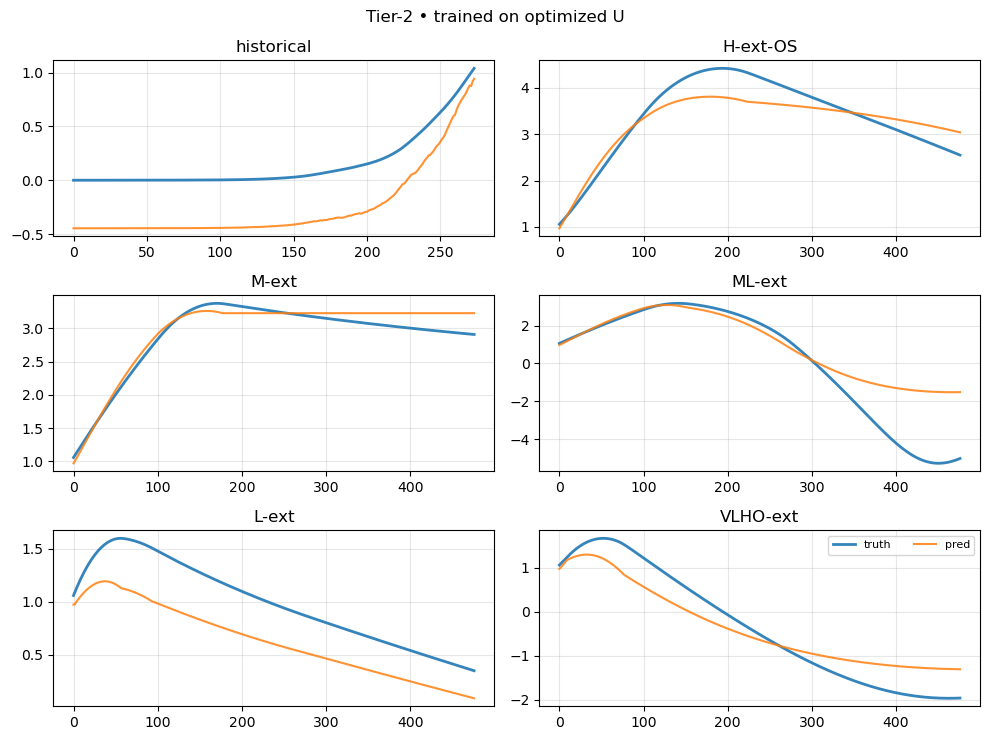

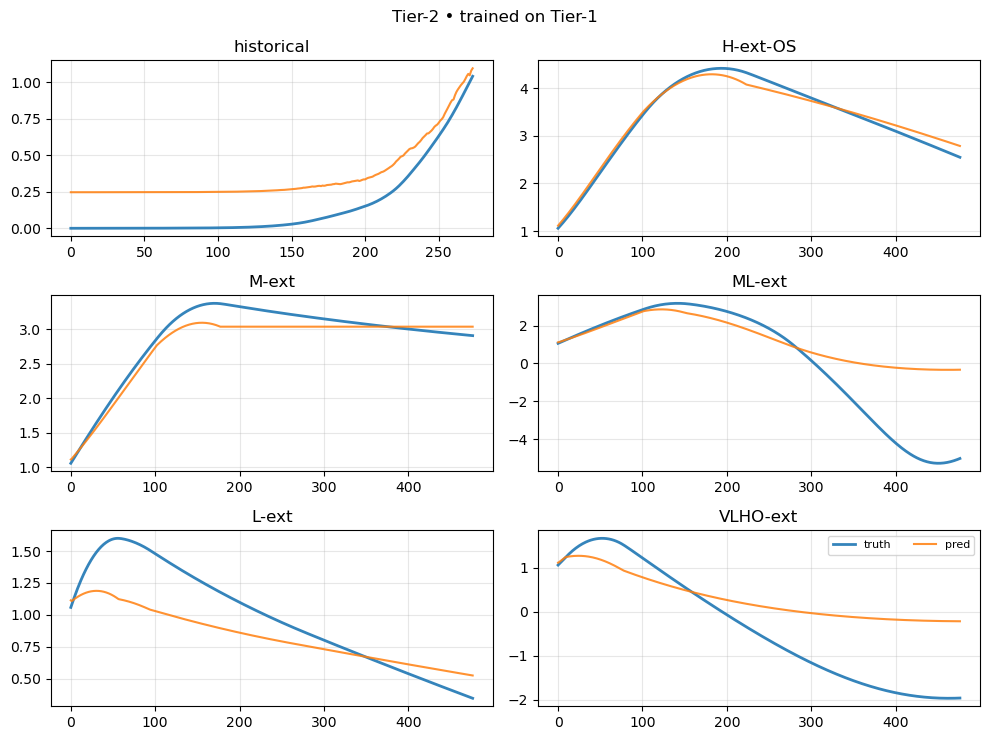

In [145]:
# ==== Evaluate the final optimized profile on Tier-2 & a Tier-1-trained model on Tier-2 ====

def build_test_tier2_all(emis_dict_tier2, scenarios_tier2, historical_name="historical"):
    """Tier-2 dataset in the same (X, y, scen) format used elsewhere."""
    return build_dataset_from_runfair_dict(
        emis_dict_tier2, scenarios_tier2, historical_name=historical_name
    )

def eval_avg_rmse_and_preds(params, test_list):
    """Return (avg_rmse, per_scenario_preds) for a trained model on a given test list."""
    # avg RMSE
    rmses = []
    for (Xte, yte, _) in test_list:
        yhat = lstm_forward(params, Xte)
        rmses.append(jnp.sqrt(jnp.mean((yhat - yte) ** 2)))
    avg_rmse = jnp.mean(jnp.stack(rmses)) if rmses else jnp.array(0.0, dtype=jnp.float32)

    # init/final preds are the same model here, so just return final preds per scenario
    preds = []
    for (Xte, yte, scen) in test_list:
        yK = lstm_forward(params, Xte)
        preds.append({
            "scenario": scen,
            "y_true": yte,
            "y_pred": yK,
        })
    return avg_rmse, preds

def train_on_single_U_and_test_tier2(
    U_final,                   # (750,)
    params0,                   # LSTM init params
    emis_dict_tier2,
    scenarios_tier2,
    K_inner=200,
    lr_inner=5e-2,
    wd_inner=1e-2,
    historical_name="historical",
):
    """
    Train on the single optimized training scenario U_final, then evaluate on Tier-2.
    No re-optimization of U here; just a straight train→test.
    """
    # Build Tier-2 test dataset
    test_tier2 = build_test_tier2_all(emis_dict_tier2, scenarios_tier2, historical_name)

    # Build training dataset from U_final (single-scenario) and scale
    train_from_U = build_train_from_U(U_final)
    train_s, test_s, _ = split_and_scale(train_from_U, test_tier2)

    # Concatenate training tensors
    Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
    ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

    # Train inner model
    paramsK, _ = train_unrolled_lstm_sgd(
        params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
    )

    # Evaluate on Tier-2
    avg_rmse_t2, preds_t2 = eval_avg_rmse_and_preds(paramsK, test_s)
    return {
        "avg_rmse_tier2": float(avg_rmse_t2),
        "preds_tier2": preds_t2,   # list of {scenario, y_true, y_pred}
        "trained_params": paramsK
    }

def train_on_tier1_and_test_tier2(
    params0,
    emis_dict_tier1, scenarios_tier1,
    emis_dict_tier2, scenarios_tier2,
    K_inner=200,
    lr_inner=5e-2,
    wd_inner=1e-2,
    historical_name="historical",
):
    """
    Train on the full Tier-1 dataset (all scenarios) and evaluate on Tier-2.
    """
    # Build Tier-1 train dataset and Tier-2 test dataset
    train_tier1 = build_dataset_from_runfair_dict(
        emis_dict_tier1, scenarios_tier1, historical_name=historical_name
    )
    test_tier2  = build_test_tier2_all(
        emis_dict_tier2, scenarios_tier2, historical_name=historical_name
    )

    # Scale with Tier-1 stats; apply to Tier-2
    train_s, test_s, _ = split_and_scale(train_tier1, test_tier2)

    # Concatenate Tier-1 training tensors
    Xtr = jnp.concatenate([X for (X, _, _) in train_s], axis=0).astype(jnp.float32)
    ytr = jnp.concatenate([y for (_, y, _) in train_s], axis=0).astype(jnp.float32)

    # Train inner model
    paramsK, _ = train_unrolled_lstm_sgd(
        params0, Xtr, ytr, K=K_inner, lr=lr_inner, weight_decay=wd_inner
    )

    # Evaluate on Tier-2
    avg_rmse_t2, preds_t2 = eval_avg_rmse_and_preds(paramsK, test_s)
    return {
        "avg_rmse_tier2": float(avg_rmse_t2),
        "preds_tier2": preds_t2,   # list of {scenario, y_true, y_pred}
        "trained_params": paramsK
    }

def plot_tier2_eval(preds, title="Tier-2 evaluation"):
    """Simple overlay of truth vs prediction for each Tier-2 scenario."""
    import numpy as np, matplotlib.pyplot as plt
    n = len(preds)
    ncols = 2
    nrows = int(np.ceil(n / ncols)) if n > 0 else 1
    plt.figure(figsize=(5*ncols, 2.5*nrows))
    for i, rec in enumerate(preds, 1):
        ax = plt.subplot(nrows, ncols, i)
        y  = np.asarray(rec["y_true"])
        yK = np.asarray(rec["y_pred"])
        ax.plot(y,  label="truth", lw=2, alpha=0.9)
        ax.plot(yK, label="pred",  alpha=0.85)
        ax.set_title(rec["scenario"])
        ax.grid(True, alpha=0.3)
    if n > 0:
        plt.legend(ncol=2, fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()

# ==== Example usage (no re-optimization) =====================================
# 1) Take final optimized training profile from the previous run:
U_final = results_allsets["U_traj"][-1]

# 2) Evaluate that single-U-trained model on Tier-2:
tier2_eval_from_U = train_on_single_U_and_test_tier2(
    U_final=U_final,
    params0=params0,
    emis_dict_tier2=emis_dict_tier2,
    scenarios_tier2=scenarios_tier2,
    K_inner=200, lr_inner=5e-2, wd_inner=1e-2,
)
print("Tier-2 avg RMSE (trained on final U):", tier2_eval_from_U["avg_rmse_tier2"])
plot_tier2_eval(tier2_eval_from_U["preds_tier2"], title="Tier-2 • trained on optimized U")

# 3) Train on full Tier-1 (all scenarios) and test on Tier-2:
tier2_eval_from_tier1 = train_on_tier1_and_test_tier2(
    params0=params0,
    emis_dict_tier1=emis_dict_tier1, scenarios_tier1=scenarios_tier1,
    emis_dict_tier2=emis_dict_tier2, scenarios_tier2=scenarios_tier2,
    K_inner=200, lr_inner=5e-2, wd_inner=1e-2,
)
print("Tier-2 avg RMSE (trained on Tier-1):", tier2_eval_from_tier1["avg_rmse_tier2"])
plot_tier2_eval(tier2_eval_from_tier1["preds_tier2"], title="Tier-2 • trained on Tier-1")


In [128]:
agents = ['CO2']
emis_dict_DECK = run_fair.load_DECK_CMIP7(agents)
scenarios_DECK = list(emis_dict_DECK.keys())
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, agents, MIP='DECK')

scenarios_DECK_subset = []
for scen in scenarios_DECK:
  if scen == 'historical':
    continue
  for a in agents:
    if a not in scen:
      continue
    else:
      scenarios_DECK_subset.append(scen)

DECK subset avg RMSE (model trained on optimized U): 1.2283408641815186
DECK subset avg RMSE (model trained on Tier-1): 0.2749192714691162


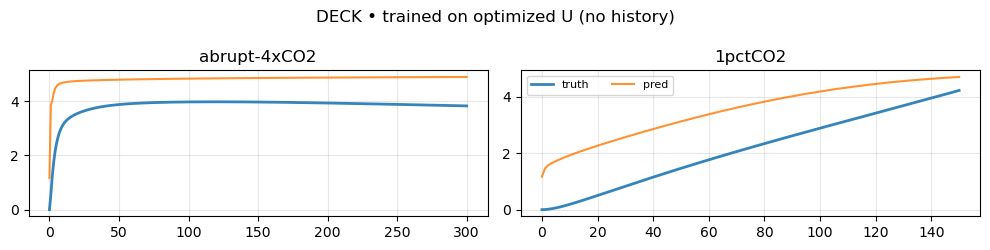

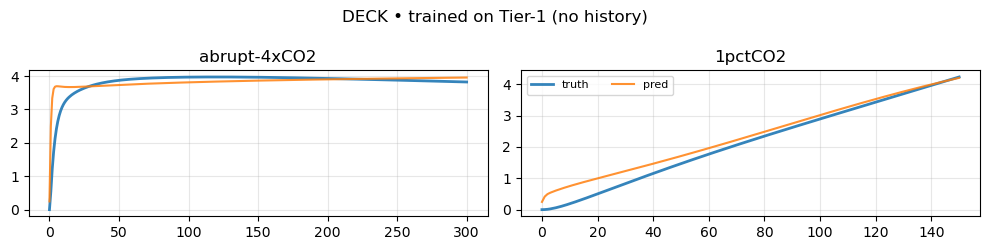

In [146]:
# ==== Build DECK subset (NO historical prepended) and evaluate =================

def build_dataset_no_history(emis_dict, scenarios):
    """
    Build (X, y, scen) where X = [E_gtco2, cumulative E_gtco2] for *current* scenario ONLY,
    and y is the simulator target using ONLY the current scenario emissions.
    No historical emissions are prepended or used.
    """
    dataset = []
    for scen in scenarios:
        years_cur, E_cur = extract_years_and_E_gtco2(emis_dict[scen])
        # features from current-only emissions
        X = make_features_E_and_cum_gtco2(E_cur, E_gtco2_hist=None)
        # targets from current-only emissions
        y = simulate_targets_gmst_from_gtco2(
            years_curr=years_cur,
            E_gtco2_curr=E_cur,
            years_hist=None,
            E_gtco2_hist=None
        )
        N = min(X.shape[0], y.shape[0])
        dataset.append((X[:N], y[:N], scen))
    return dataset

def build_test_DECK_subset_nohist(emis_dict_DECK, scenarios_DECK_subset):
    """Wrapper for DECK subset with no historical prepended."""
    # ensure "historical" is excluded
    scenarios = [s for s in scenarios_DECK_subset if s != "historical"]
    return build_dataset_no_history(emis_dict_DECK, scenarios)

def evaluate_params_on_test_with_train_scaler(params, train_dataset, test_dataset):
    """
    Apply the *train* scaler (fit on train_dataset) to the test_dataset,
    then evaluate avg RMSE and per-scenario preds using the provided params.
    """
    train_s, test_s, _ = split_and_scale(train_dataset, test_dataset)
    avg_rmse, preds = eval_avg_rmse_and_preds(params, test_s)
    return float(avg_rmse), preds

def plot_deck_eval(preds, title="DECK subset evaluation (no history)"):
    """Overlay truth vs prediction for each DECK scenario (no history)."""
    import numpy as np, matplotlib.pyplot as plt
    n = len(preds); ncols = 2; nrows = int(np.ceil(n / ncols)) if n > 0 else 1
    plt.figure(figsize=(5*ncols, 2.5*nrows))
    for i, rec in enumerate(preds, 1):
        ax = plt.subplot(nrows, ncols, i)
        y  = np.asarray(rec["y_true"])
        yK = np.asarray(rec["y_pred"])
        ax.plot(y,  label="truth", lw=2, alpha=0.9)
        ax.plot(yK, label="pred",  alpha=0.85)
        ax.set_title(rec["scenario"])
        ax.grid(True, alpha=0.3)
    if n > 0:
        plt.legend(ncol=2, fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()

# ---- Prepare DECK subset (no history) ---------------------------------------
# If you've already built `scenarios_DECK_subset` externally, you can reuse it.
# Otherwise, a simple default is: all non-historical DECK scenarios.

deck_subset_nohist = build_test_DECK_subset_nohist(
    emis_dict_DECK, scenarios_DECK_subset
)

# ---- 1) Evaluate model trained on optimized single scenario U_final ----------
# Rebuild the *training* dataset used for this model (so scaler matches training):
train_from_U_final = build_train_from_U(results_allsets["U_traj"][-1])
params_trained_on_U = train_on_single_U_and_test_tier2(
    U_final=results_all["U_traj"][-1],
    params0=params0,
    emis_dict_tier2=emis_dict_tier2,
    scenarios_tier2=scenarios_tier2,
    K_inner=200, lr_inner=5e-2, wd_inner=1e-2,
)["trained_params"]

avg_rmse_deck_U, preds_deck_U = evaluate_params_on_test_with_train_scaler(
    params_trained_on_U, train_from_U_final, deck_subset_nohist
)
print("DECK subset avg RMSE (model trained on optimized U):", avg_rmse_deck_U)
plot_deck_eval(preds_deck_U, title="DECK • trained on optimized U (no history)")

# ---- 2) Evaluate model trained on ALL Tier-1 scenarios ----------------------
# Rebuild Tier-1 train dataset (so scaler matches this training):
train_tier1_all = build_dataset_from_runfair_dict(
    emis_dict_tier1, scenarios_tier1, historical_name="historical"
)
params_trained_on_tier1 = train_on_tier1_and_test_tier2(
    params0=params0,
    emis_dict_tier1=emis_dict_tier1, scenarios_tier1=scenarios_tier1,
    emis_dict_tier2=emis_dict_tier2, scenarios_tier2=scenarios_tier2,
    K_inner=200, lr_inner=5e-2, wd_inner=1e-2,
)["trained_params"]

avg_rmse_deck_T1, preds_deck_T1 = evaluate_params_on_test_with_train_scaler(
    params_trained_on_tier1, train_tier1_all, deck_subset_nohist
)
print("DECK subset avg RMSE (model trained on Tier-1):", avg_rmse_deck_T1)
plot_deck_eval(preds_deck_T1, title="DECK • trained on Tier-1 (no history)")
